# **Object Detection for Pipelining and Instrumentation Diagram (P&ID)**

**Objective:** Given a set of P&ID Diagrams, the task is to detect the P&ID components in the diagram using bounding boxes


**Approach:** Used a Pre Trained model called You Look Only Once (YOLO) for object detection.

**Related Paper :** [Object_Detection_for_PampID_Images_using_various_Deep_Learning_Techniques](https://drive.google.com/file/d/1gjI_9nm5s3VXkm-Q2Bcm26z_m6iQeaF6/view?usp=sharing)


Step 1: Ensure that the runtime is connected to GPU

In [ ]:
!nvidia-smi

Sat Oct 26 01:50:48 2024       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.104.05             Driver Version: 535.104.05   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  Tesla T4                       Off | 00000000:00:04.0 Off |                    0 |
| N/A   52C    P8              10W /  70W |      0MiB / 15360MiB |      0%      Default |
|                                         |                      |                  N/A |
+-----------------------------------------+----------------------+--

Step 2: Keeping track of the home directory

In [ ]:
import os
HOME = os.getcwd()
print(HOME)

/content


In [ ]:
!pip install ultralytics

from IPython import display
display.clear_output()
!yolo mode=checks

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Traceback (most recent call last):
  File "/usr/local/bin/yolo", line 8, in <module>
    sys.exit(entrypoint())
  File "/usr/local/lib/python3.10/dist-packages/ultralytics/cfg/__init__.py", line 765, in entrypoint
    raise ValueError(f"Invalid 'mode={mode}'. Valid modes are {MODES}.\n{CLI_HELP_MSG}")
ValueError: Invalid 'mode=<module 'ultralytics.utils.checks' from '/usr/local/lib/python3.10/dist-packages/ultralytics/utils/checks.py'>'. Valid modes are {'train', 'export', 'predict', 'benchmark', 'track', 'val'}.

    Arguments received: ['yolo', 'mode=checks']. Ultralytics 'yolo' commands use the following syntax:

        yolo TASK MODE ARGS

        Where   TASK (optional) is o

Step 3: Import YOLO for training and prediction, and display functions for showing image

In [ ]:
from ultralytics import YOLO

from IPython.display import display, Image

Step 4: Train YOLO model for P & ID symbols

In [ ]:
# %cd {HOME}

!yolo task=detect mode=train model=yolov8n.pt data=/content/drive/MyDrive/ComputerVisionAndImageAnalysis/Package/Dataset/data.yaml epochs=25

Ultralytics 8.3.20 🚀 Python-3.10.12 torch-2.4.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
engine/trainer: task=detect, mode=train, model=yolov8n.pt, data=/content/drive/MyDrive/ComputerVisionAndImageAnalysis/Package/Dataset/data.yaml, epochs=25, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train2, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_cr

Step 5: Model building and allocating 25% of the dataset for testing

In [ ]:
%cd {HOME}
!yolo task=detect mode=predict model=/content/runs/detect/train2/weights/best.pt conf=0.25 source=/content/drive/MyDrive/ComputerVisionAndImageAnalysis/Package/Dataset/test/images

/content
Ultralytics 8.3.20 🚀 Python-3.10.12 torch-2.4.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
Model summary (fused): 168 layers, 3,006,623 parameters, 0 gradients, 8.1 GFLOPs

image 1/27 /content/drive/MyDrive/ComputerVisionAndImageAnalysis/Package/Dataset/test/images/3-way-valve-120_png.rf.a027ab99cafee0808204422ca0ab92b8.jpg: 640x640 4 3-way Valves, 9.0ms
image 2/27 /content/drive/MyDrive/ComputerVisionAndImageAnalysis/Package/Dataset/test/images/3-way-valve-168_png.rf.1bfbf9aa464cbc621c7aea64cae3f2d3.jpg: 640x640 2 3-way Valves, 7.5ms
image 3/27 /content/drive/MyDrive/ComputerVisionAndImageAnalysis/Package/Dataset/test/images/3-way-valve-174_png.rf.8b284e75212dd31e48cf5d210a8a0898.jpg: 640x640 2 3-way Valves, 7.5ms
image 4/27 /content/drive/MyDrive/ComputerVisionAndImageAnalysis/Package/Dataset/test/images/3-way-valve-207_png.rf.875240d12c57a4bfe0fd8edc41322408.jpg: 640x640 3 3-way Valves, 7.5ms
image 5/27 /content/drive/MyDrive/ComputerVisionAndImageAnalysis/Package/Dataset/test/image

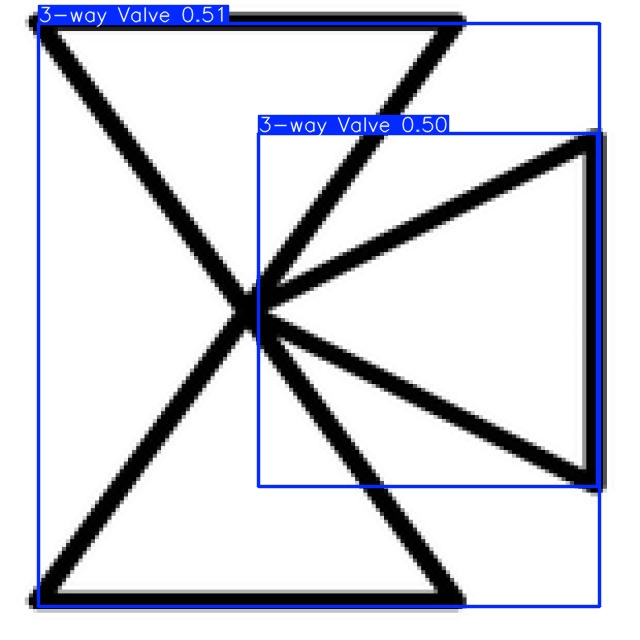

In [ ]:
import glob
from IPython.display import Image, display

for image_path in glob.glob(f'/content/runs/detect/predict/*.jpg')[:1]:
      display(Image(filename=image_path, width=600))
      print("\n")

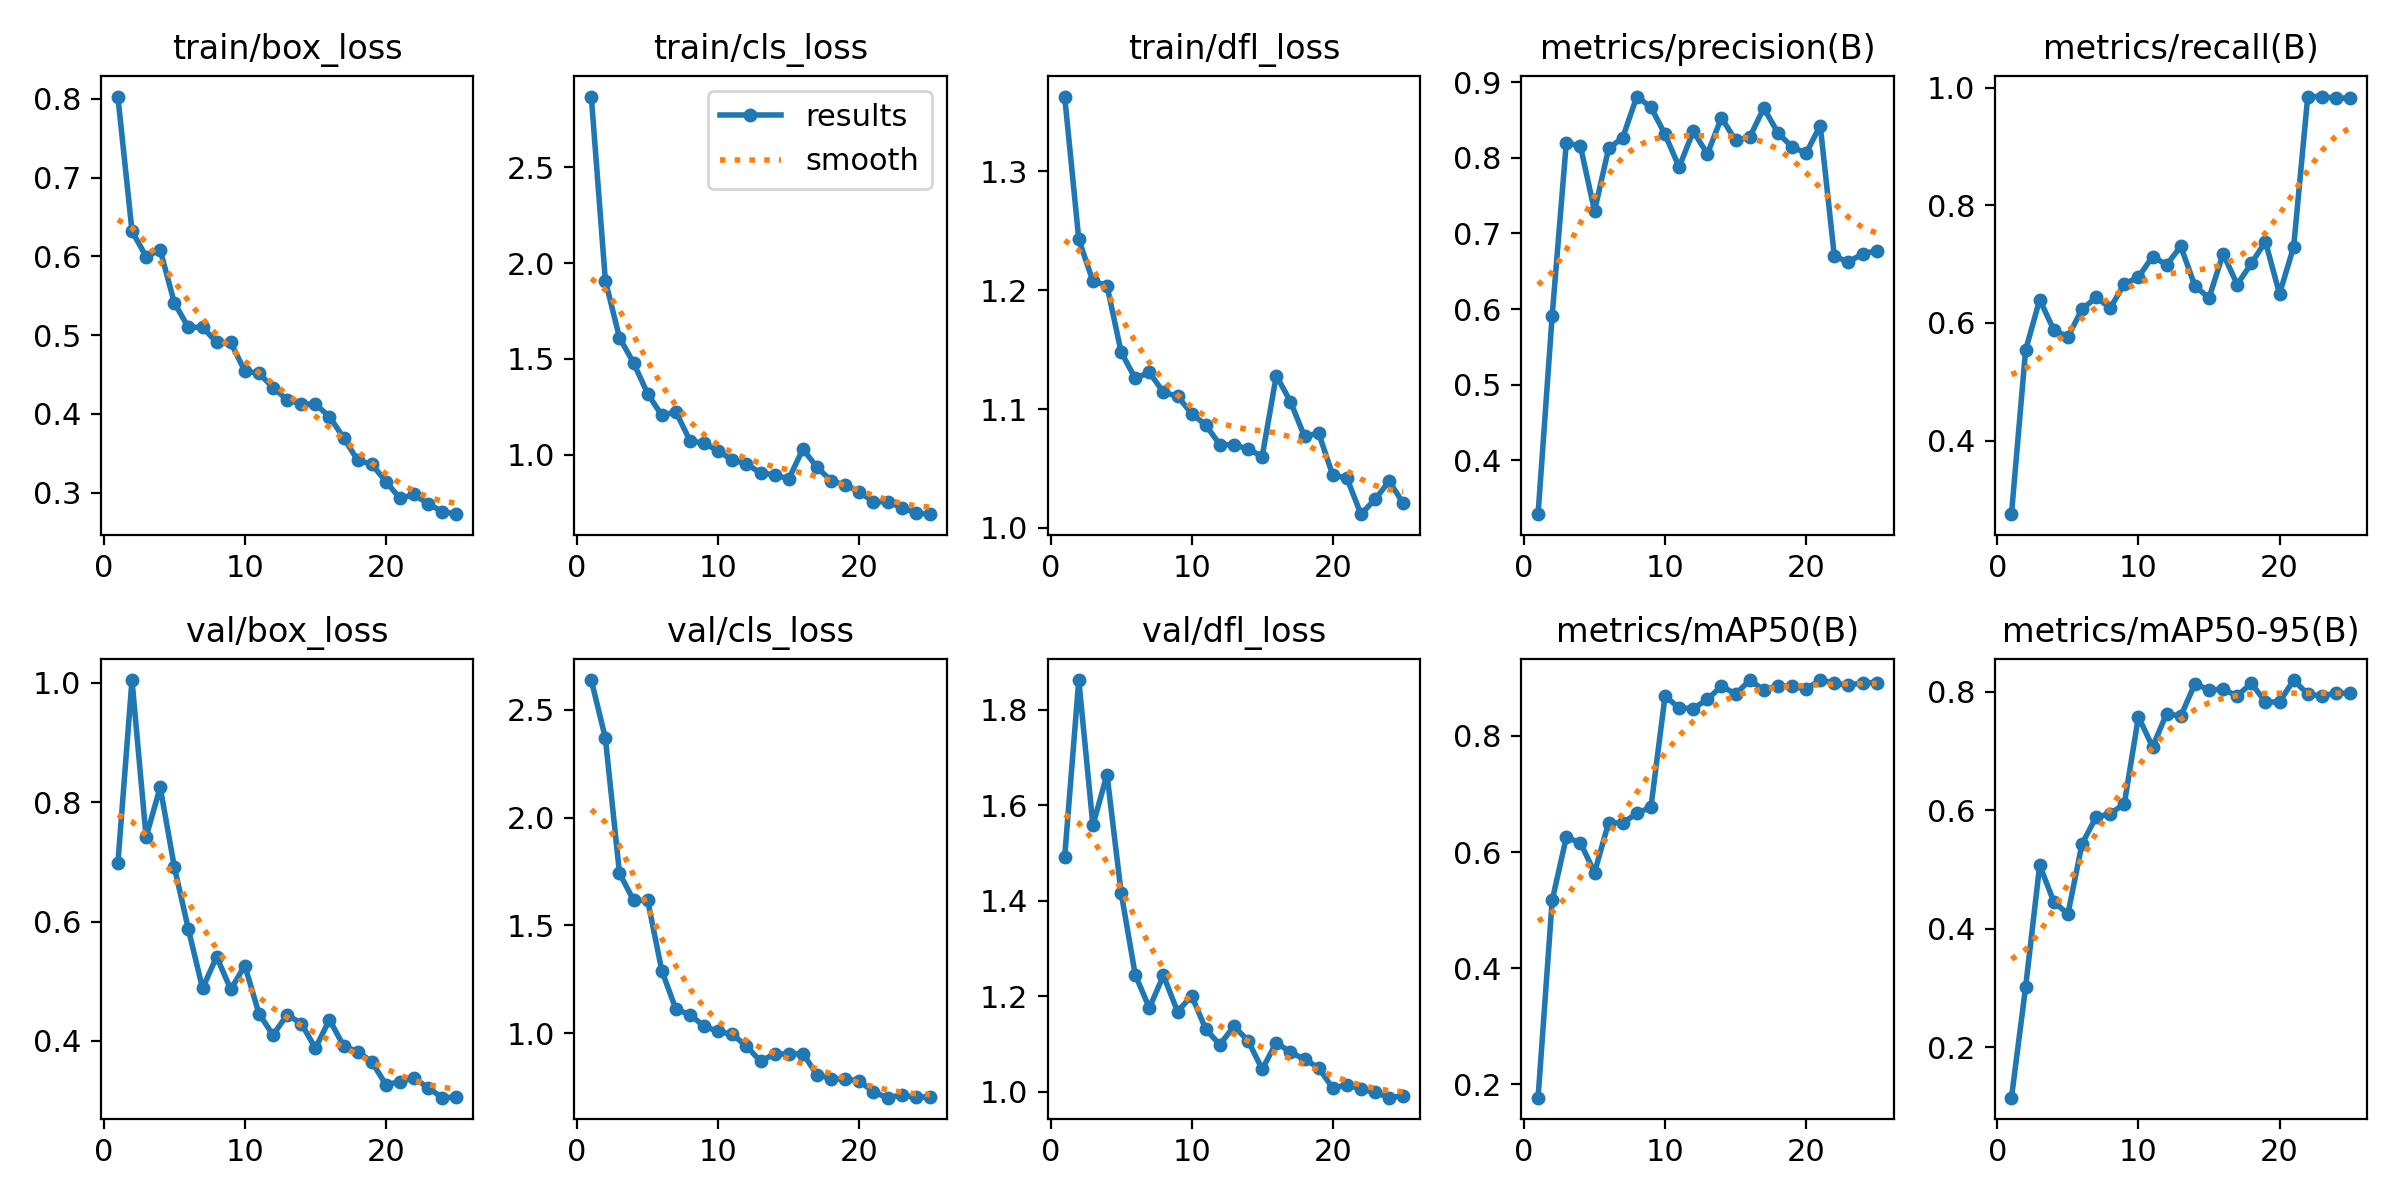

In [ ]:
Image(filename=f'/content/runs/detect/train2/results.png', width=600)

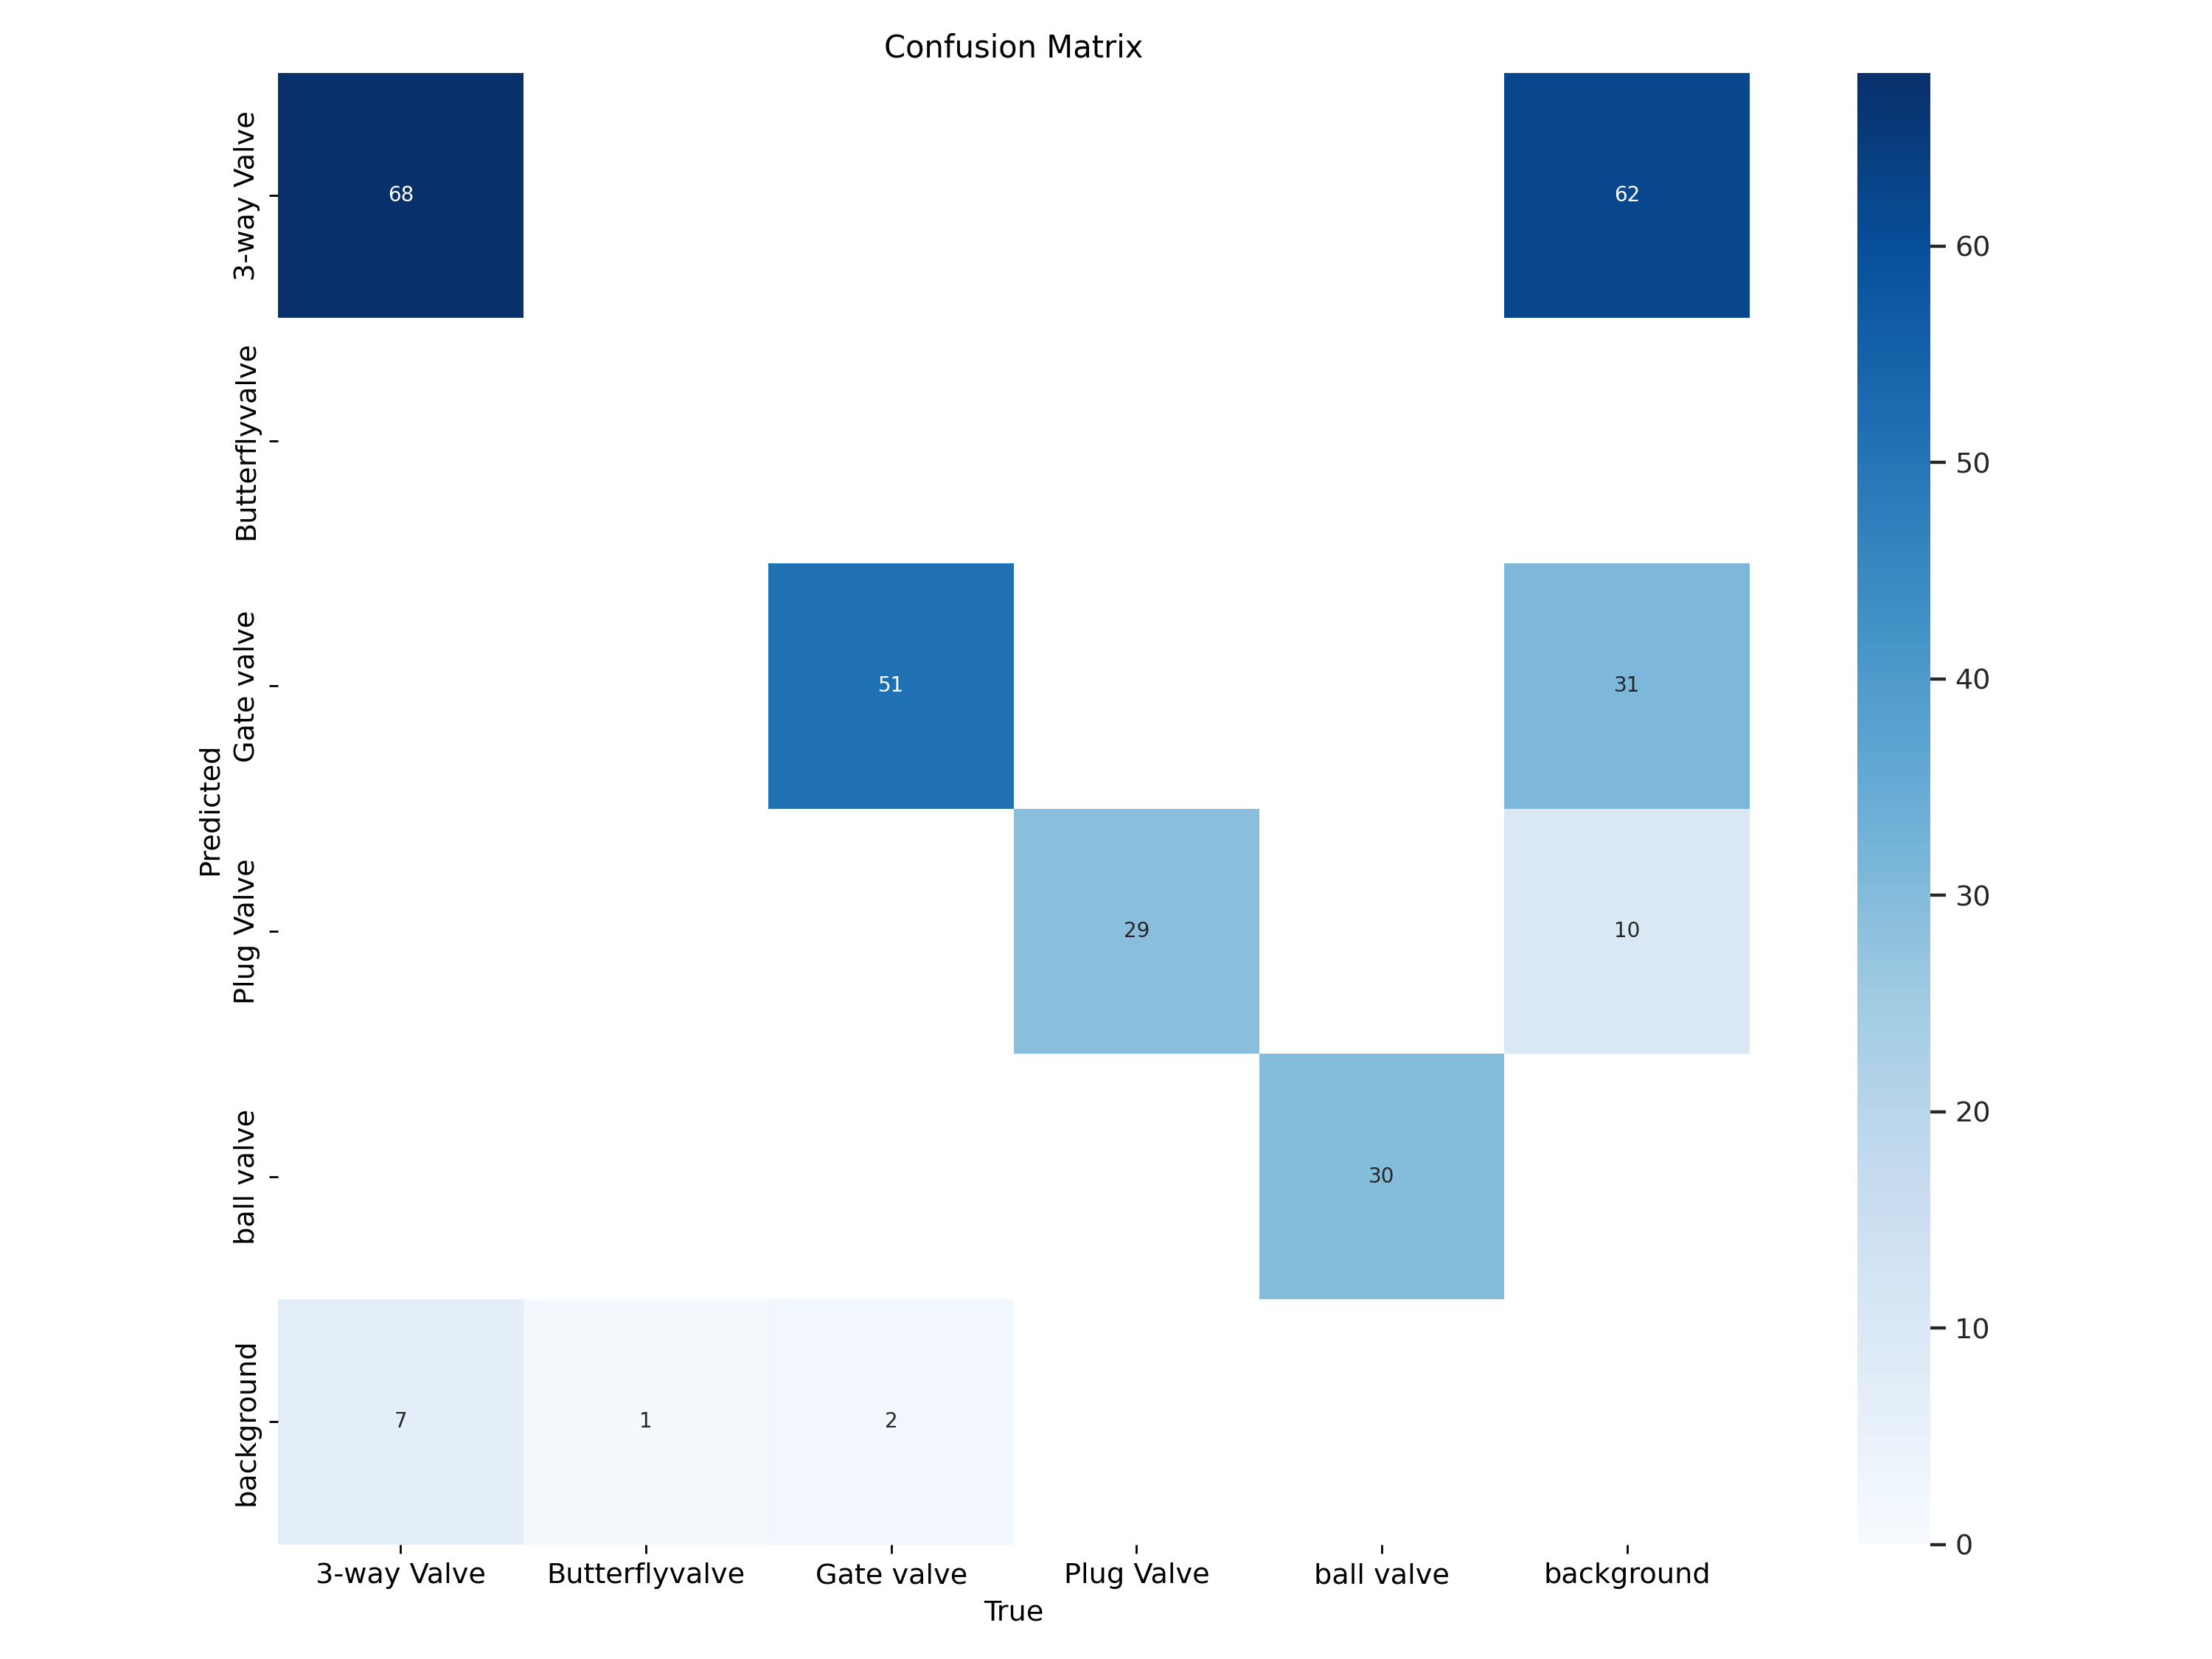

In [ ]:
Image(filename=f'/content/runs/detect/train2/confusion_matrix.png', width=600)

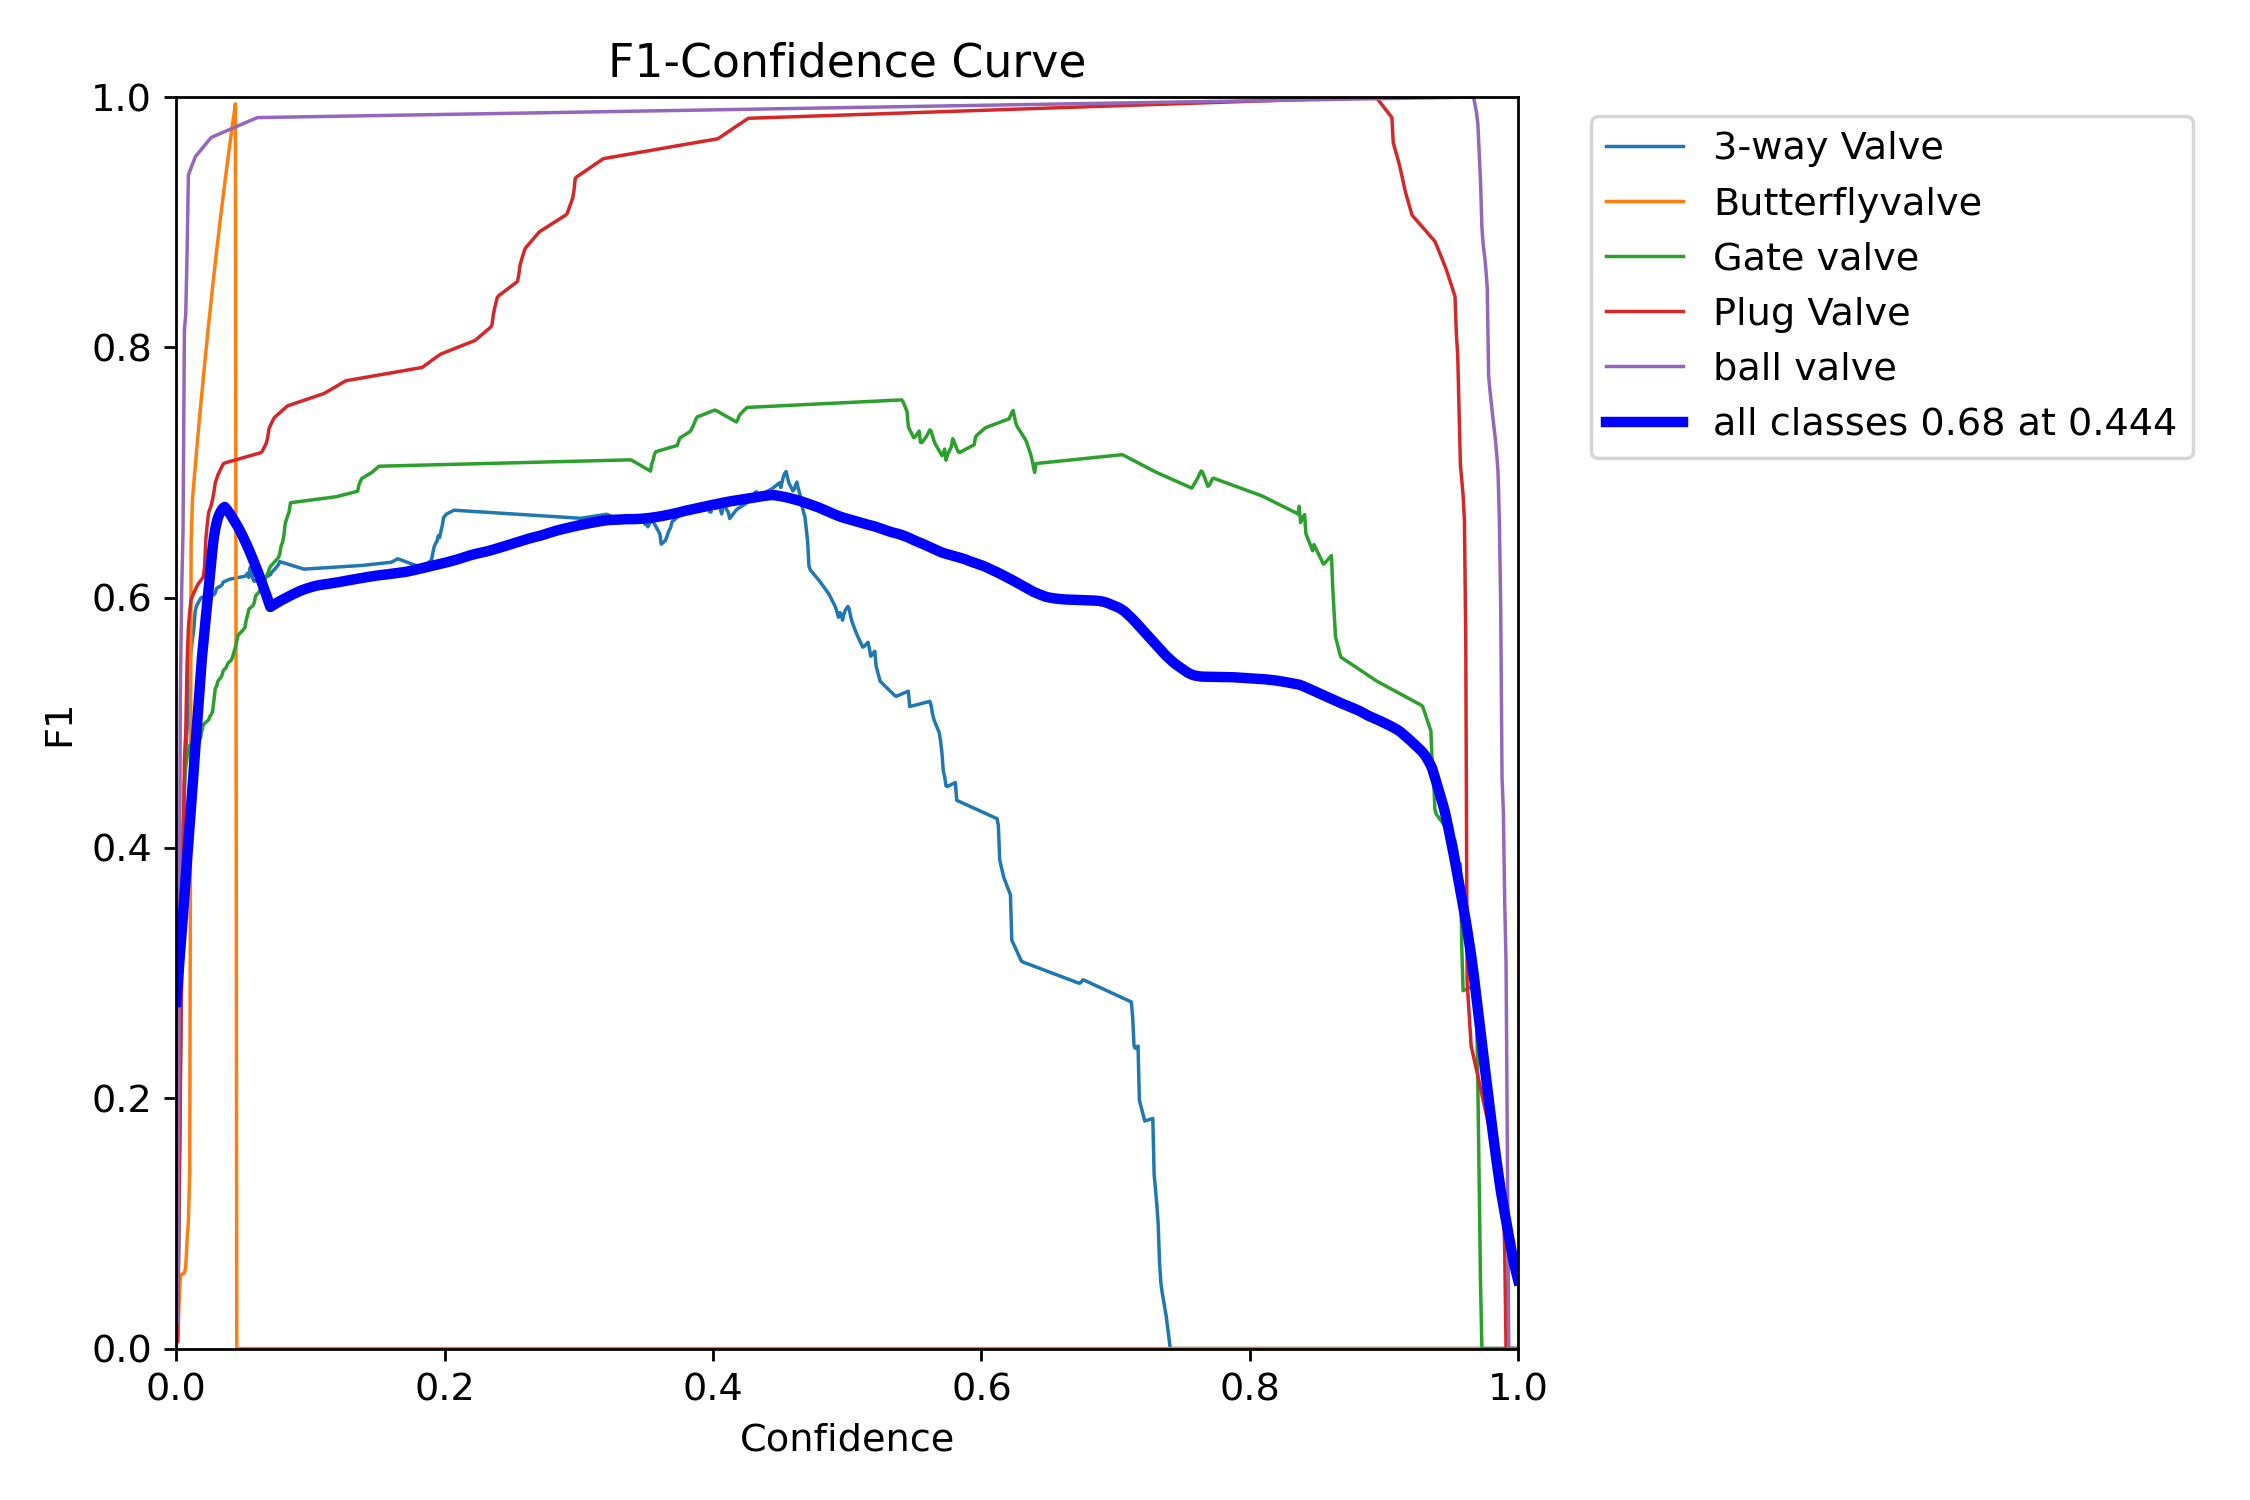

In [ ]:
Image(filename = '/content/runs/detect/train2/F1_curve.png',width = 600)

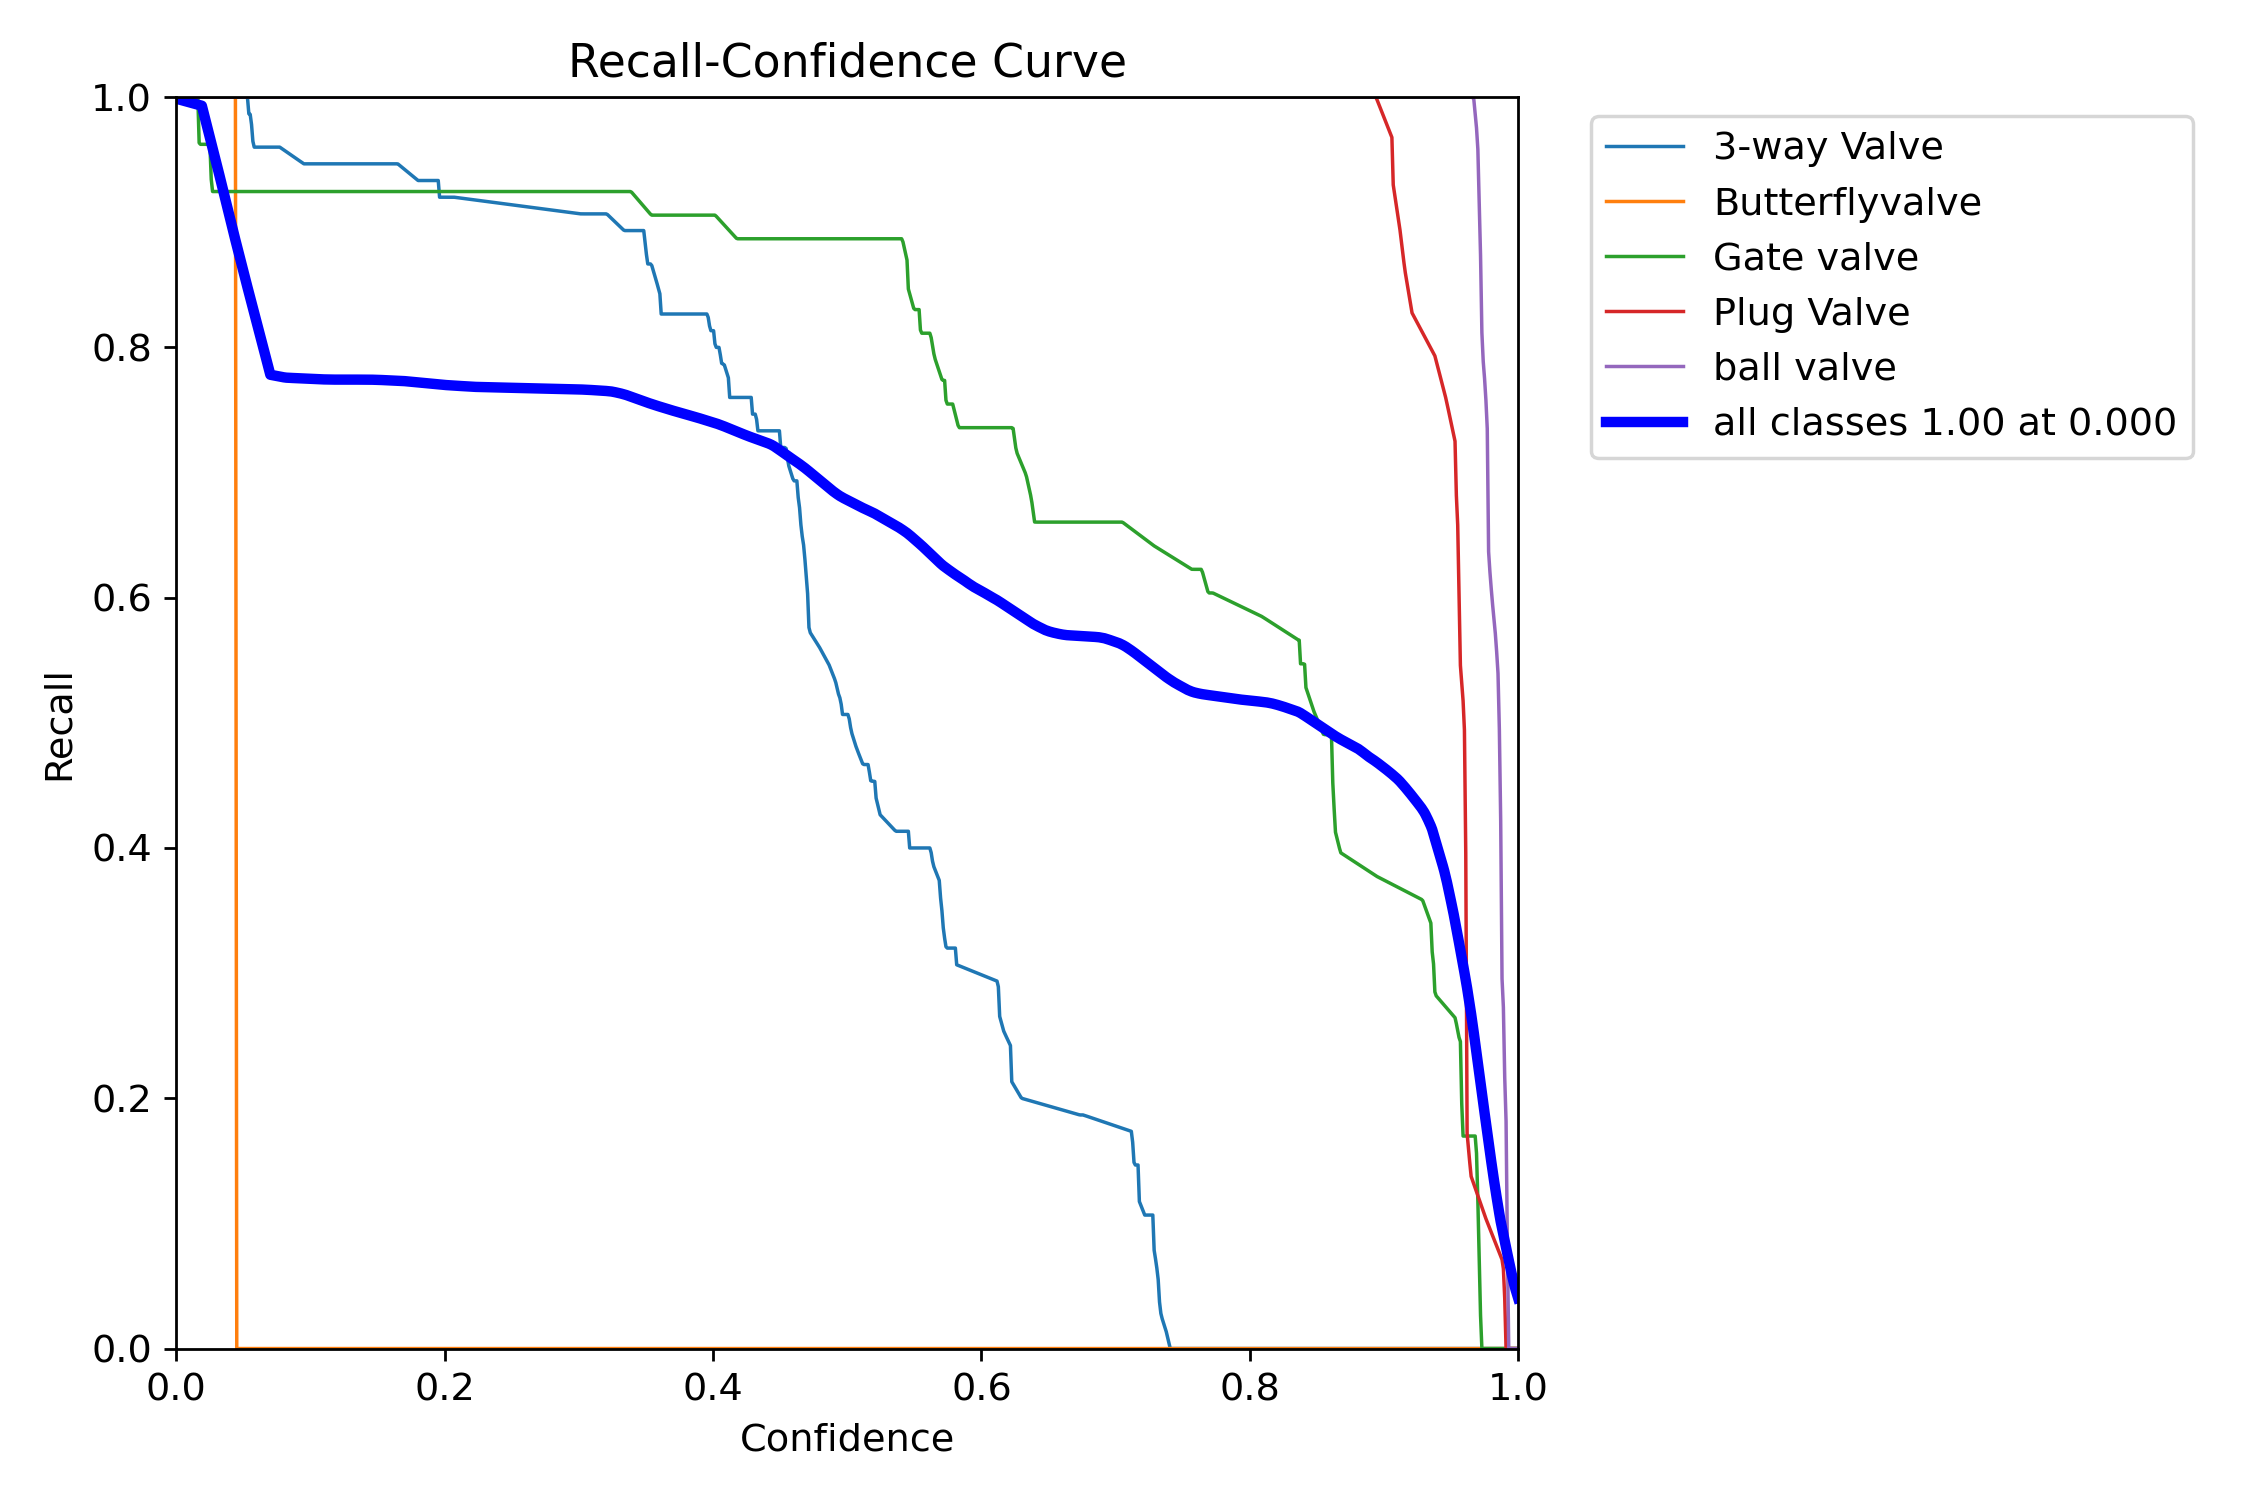

In [ ]:
Image(filename = '/content/runs/detect/train2/R_curve.png',width = 600)

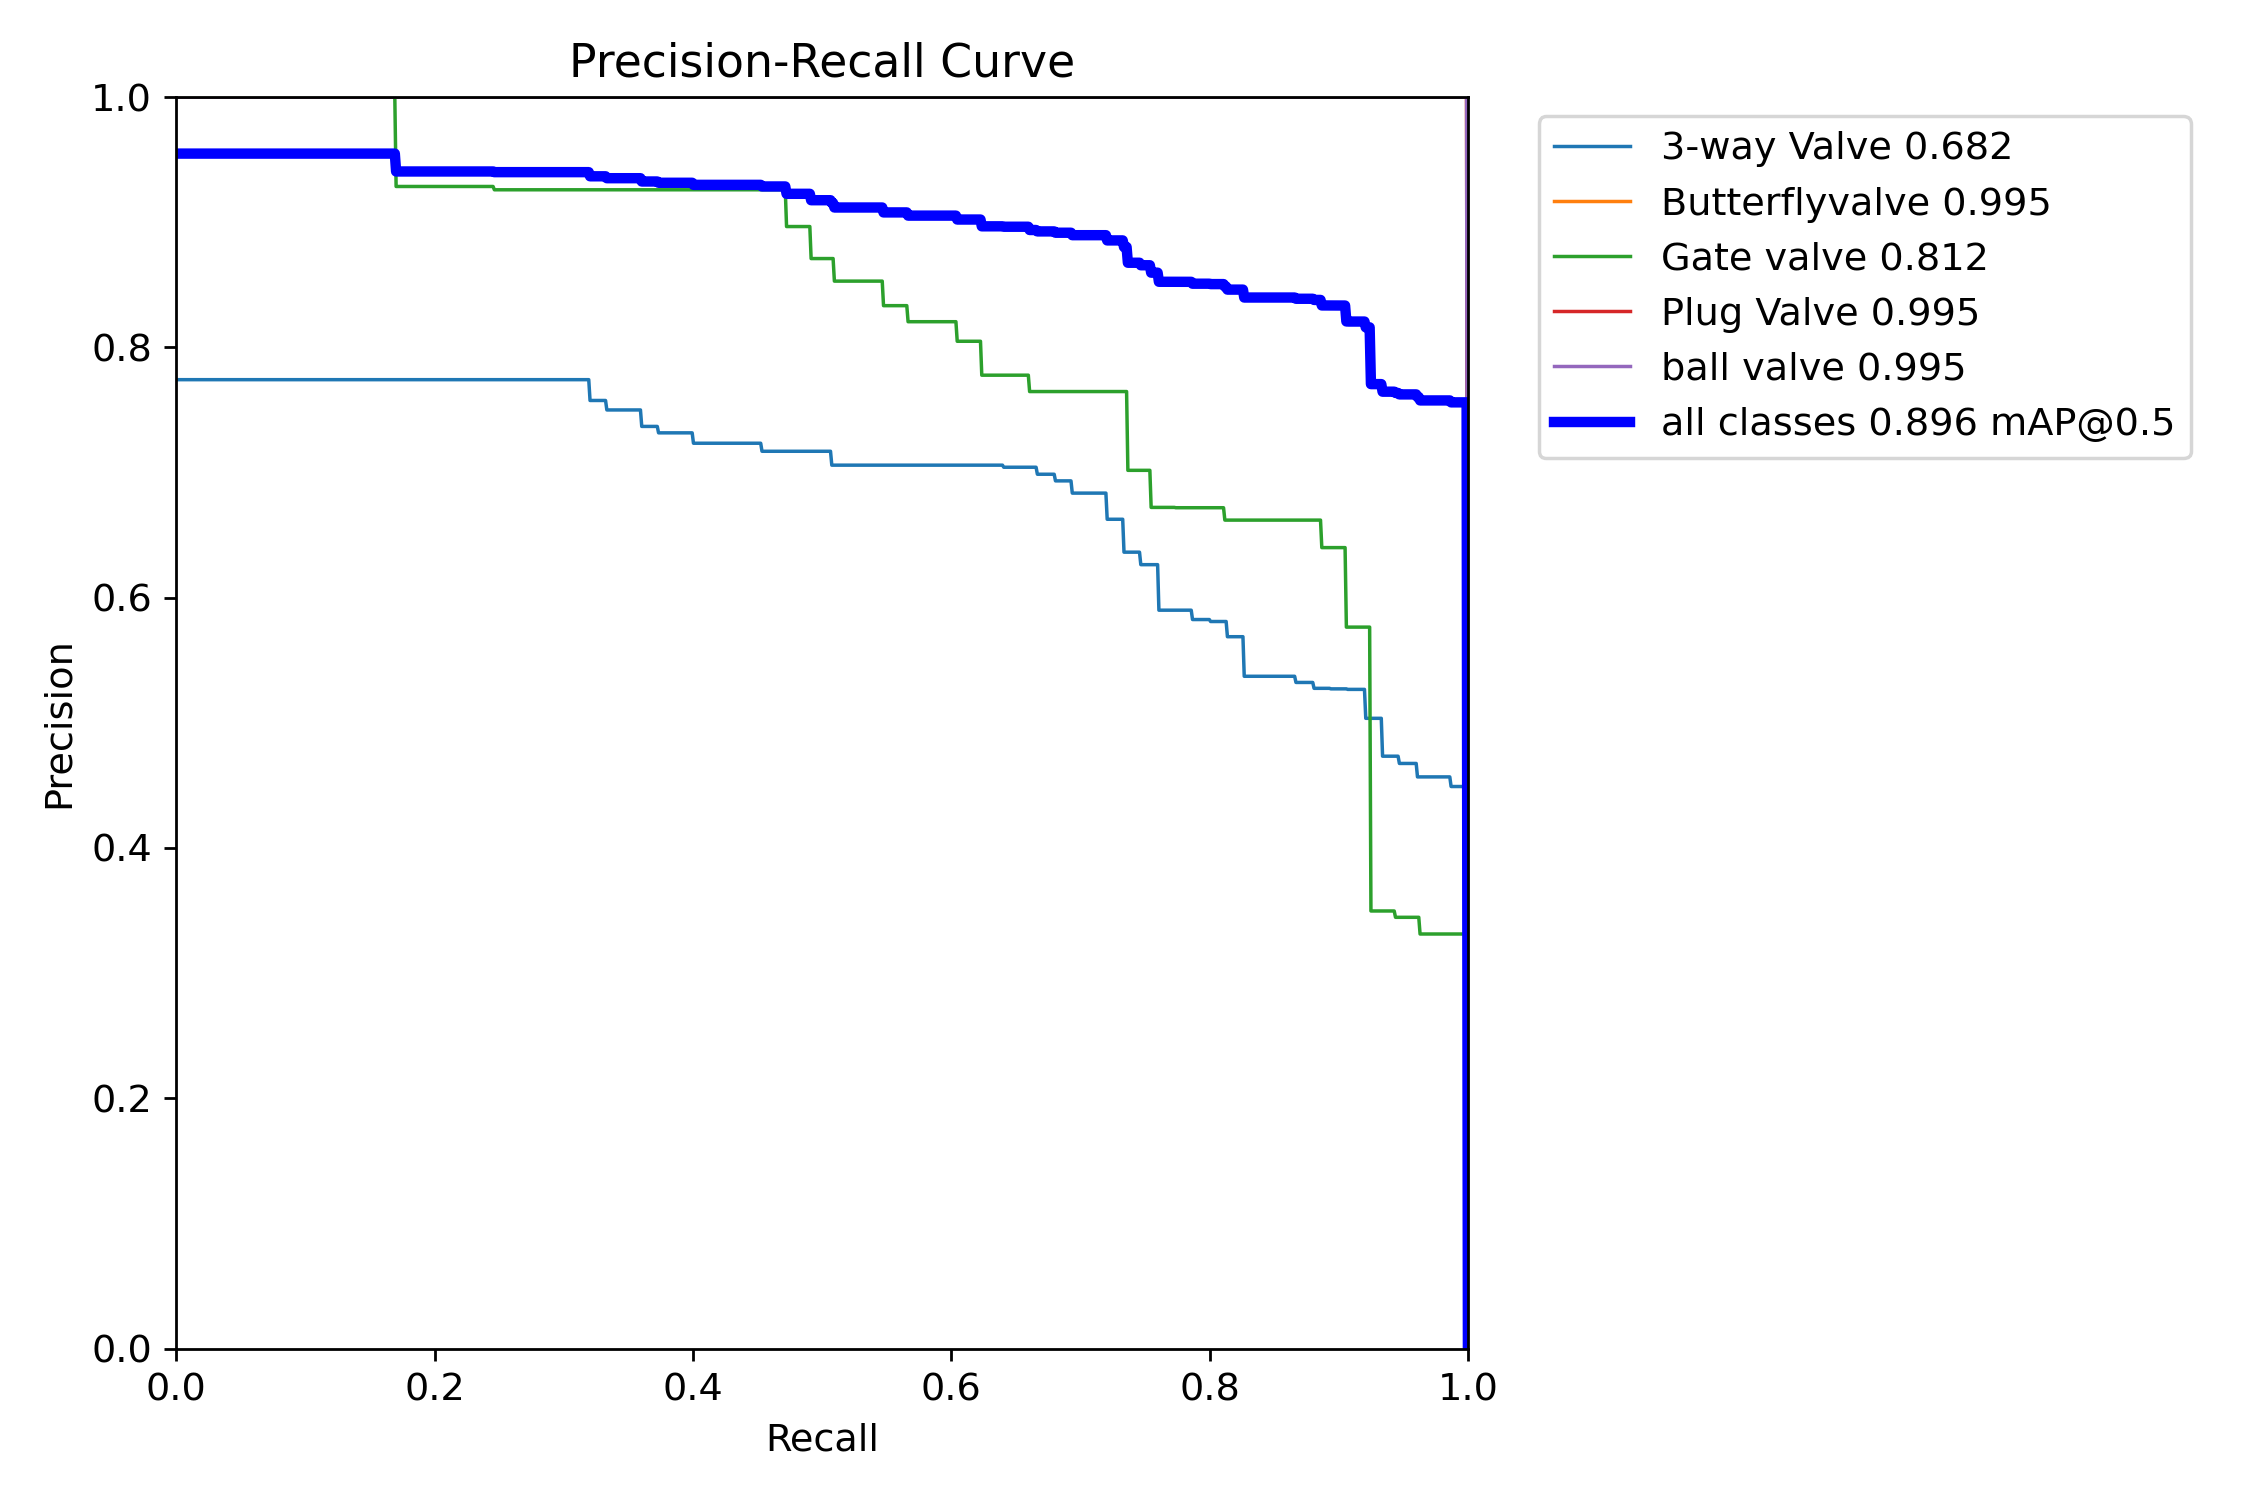

In [ ]:
Image(filename = '/content/runs/detect/train2/PR_curve.png',width = 600)

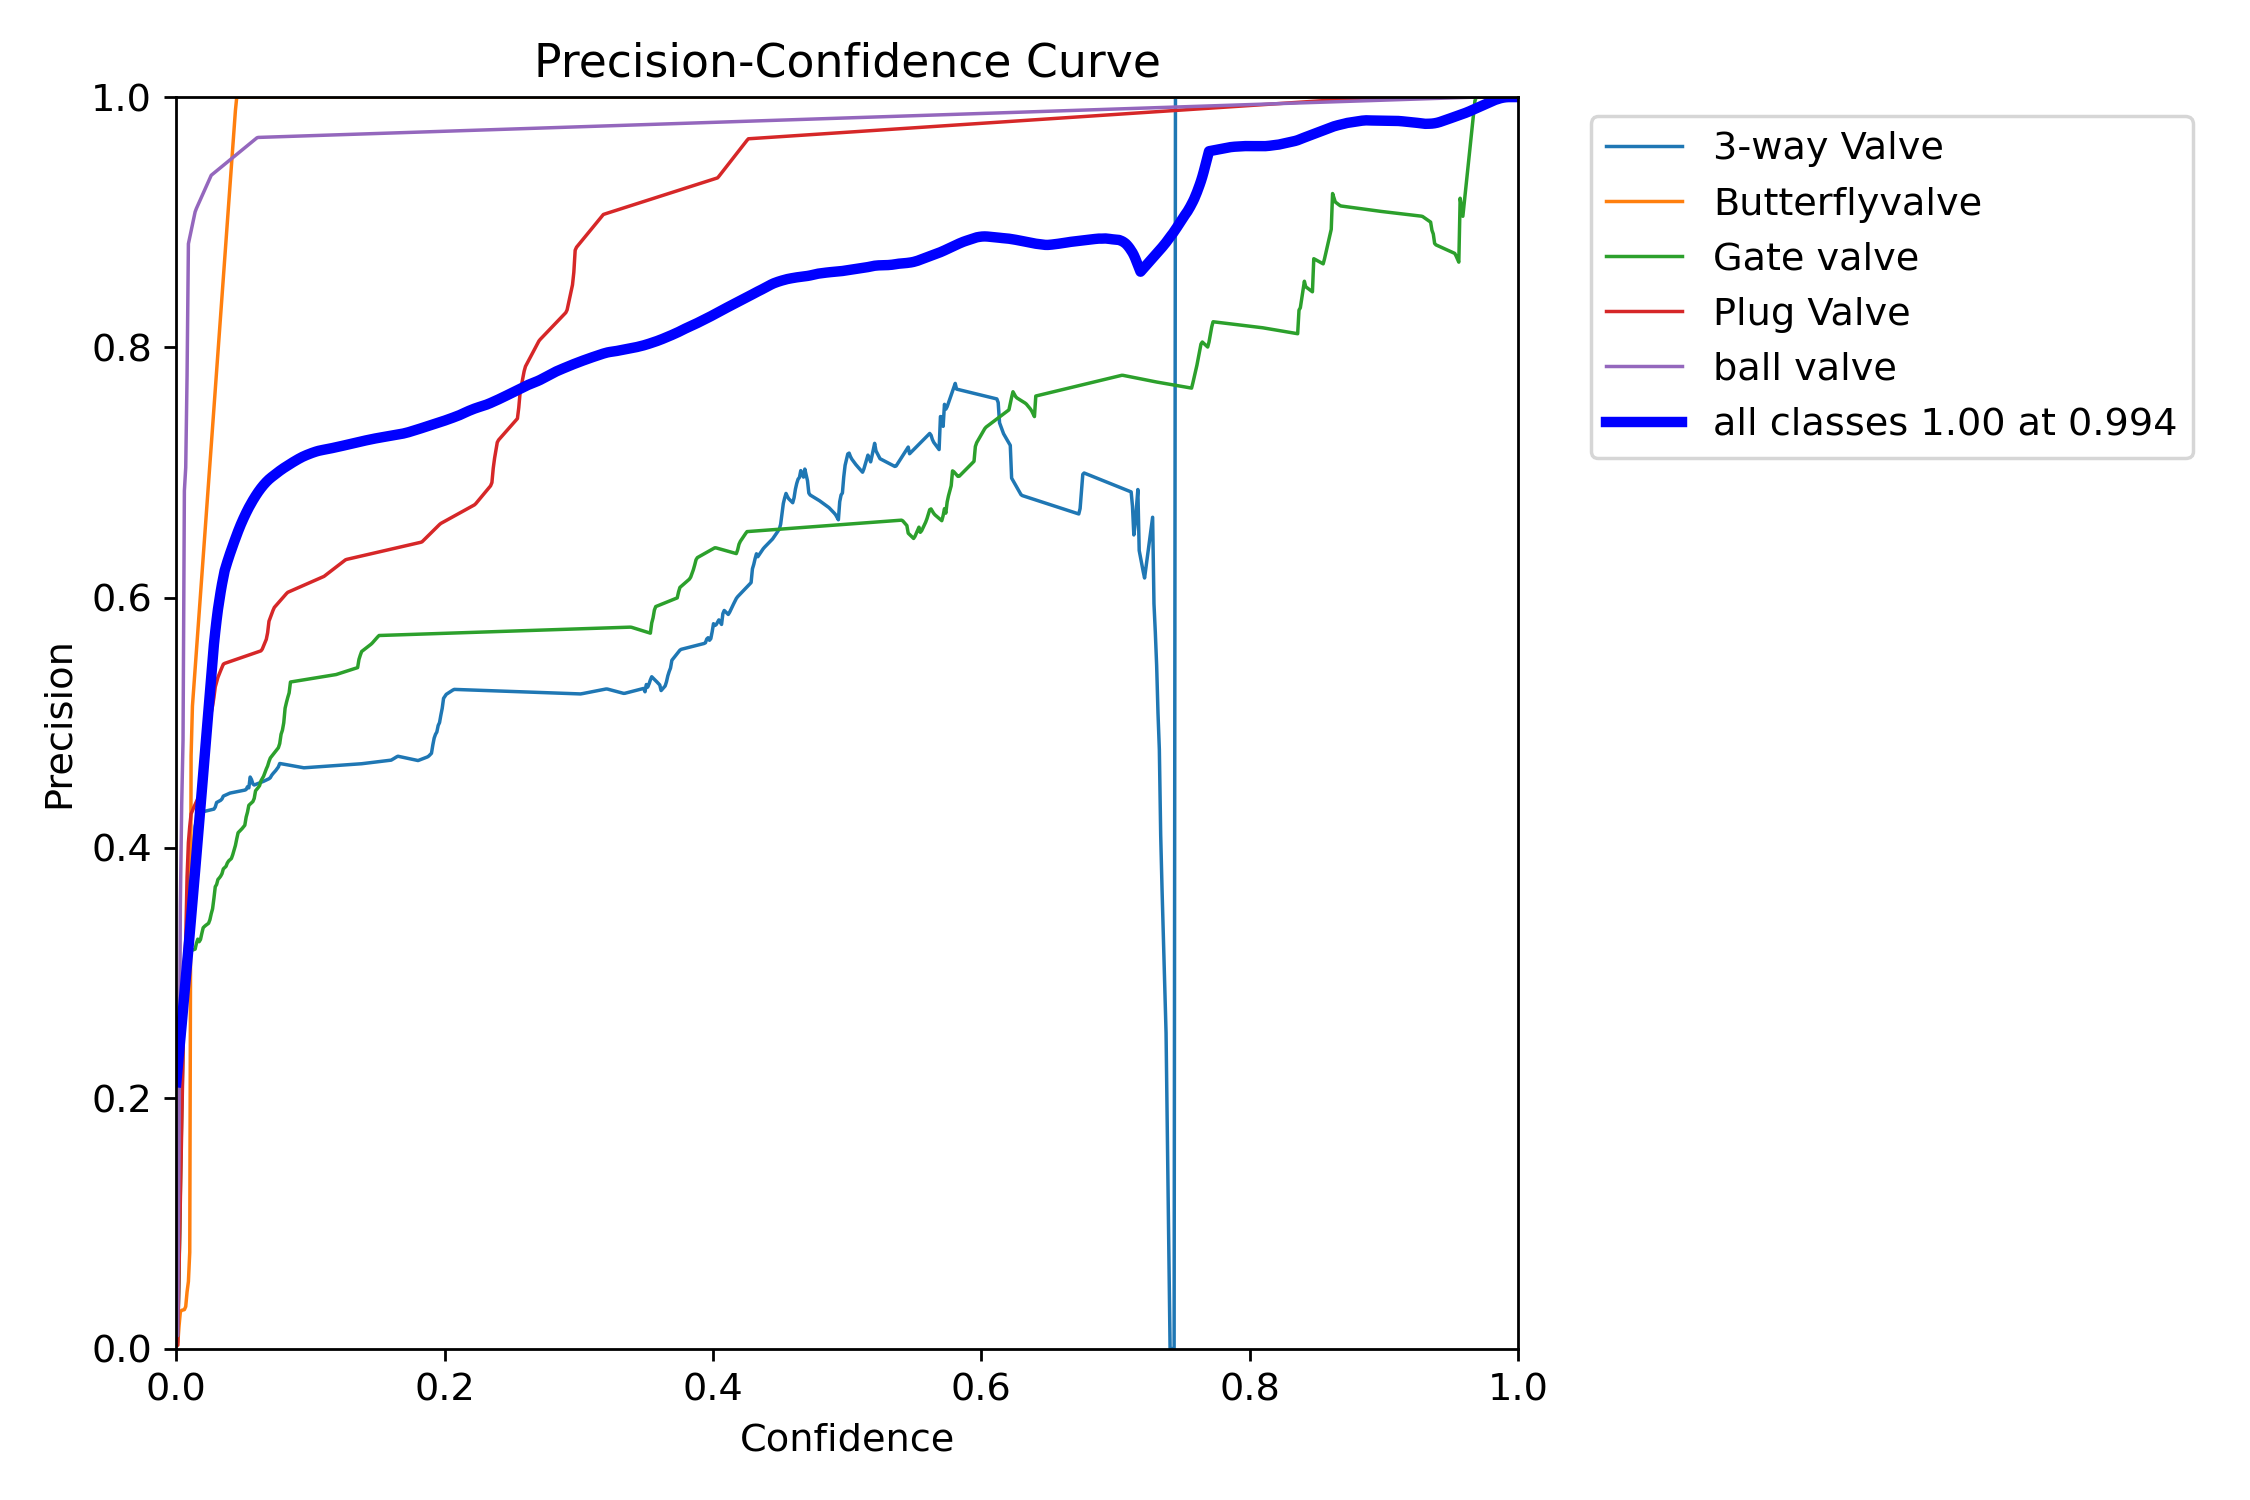

In [ ]:
Image(filename = '/content/runs/detect/train2/P_curve.png',width = 600)

# **For The Dataset in Roboflow**

In [5]:
import os
home = os.path.abspath('/content/drive/MyDrive/ComputerVisionAndImageAnalysis/Package')
%cd {home}

/content/drive/MyDrive/ComputerVisionAndImageAnalysis/Package


In [ ]:
%cd {home}
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="3nTCL71duypqfJWTCb3D")
project = rf.workspace("btp-opsv7").project("pid-symbols-wjbci")
version = project.version(1)
dataset = version.download("yolov8")


[Errno 2] No such file or directory: '{home}'
/content
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 5.3 MB/s eta 0:00:00
  Attempting uninstall: idna
    Found existing installation: idna 3.10
    Uninstalling idna-3.10:
      Successfully uninstalled idna-3.10
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to PID-Symbols-1 in yolov8:: 100%|██████████| 5650/5650 [00:00<00:00, 5734.00it/s]


In [ ]:
!pip install imgaug

In [ ]:
import glob
import os
import cv2
import imgaug
import imgaug.augmenters as iaa

import numpy as np

def preprocess_image(image_path):
    image = cv2.imread(image_path, cv2.IMREAD_COLOR)
    if image is None:
        print(f"Failed to load image: {image_path}")
        return None

    # Apply CLAHE to each channel separately
    channels = cv2.split(image)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    equalized_channels = [clahe.apply(ch) for ch in channels]
    equalized_image = cv2.merge(equalized_channels)

    # Resize to a standard size (e.g., 256x256)
    processed_image = cv2.resize(equalized_image, (256, 256))
    return processed_image



def augment_images(image_paths, output_dir):
    os.makedirs(output_dir, exist_ok=True)
    seq = iaa.Sequential([
        iaa.Affine(rotate=(-20, 20)),
        iaa.GaussianBlur(sigma=(0.0, 3.0)),
        iaa.Resize({"height": (0.8, 1.2), "width": (0.8, 1.2)}),
        iaa.AdditiveGaussianNoise(scale=(0, 0.05*255)),
        iaa.SaltAndPepper(0.02),
        # iaa.convolve(kernel=(np.ones((3, 3), dtype=np.float32))),
        iaa.Crop(percent=(0, 0.2))
    ])


    for idx, path in enumerate(image_paths):
        image = cv2.imread(path)
        if image is None:
            print(f"Failed to load image: {path}")
            continue
        augmented_image = seq(image=image)
        output_path = os.path.join(output_dir, f"{os.path.basename(path)}aug_{idx}.jpg")
        print(f'Writing File : {os.path.basename(output_path)} counter = {idx + 1}')
        cv2.imwrite(output_path, augmented_image)

def process(images,output_dir):

    counter = 0
    for image in images:
        print(f'Processing file {os.path.basename(image)} counter : {counter}')
        counter += 1
        processed = preprocess_image(image)
        if image is not None:
            cv2.imwrite(output_dir + os.path.basename(image),processed)

def copy(labels,output_dir):

    counter = 0
    for idx,image_path in enumerate(labels):
        content = None
        with open(image_path,'rb') as file:
            content = file.read()


        if content is not None:
            print(f'Copying file {os.path.basename(image_path)} counter = {counter}')
            with open(output_dir + os.path.basename(image_path),'wb') as file:
                file.write(content)
            with open(f'{output_dir}/{os.path.basename(image_path)}aug_{idx}.jpg','wb') as file:
                file.write(content)
            counter += 1

if __name__=='__main__':

    counter = 0
    home = os.path.abspath('/content/drive/MyDrive/ComputerVisionAndImageAnalysis/Package')

    output_dir = f'{home}/PID-Dataset/'



    train_images = glob.glob(f'{home}/PID-Symbols-1/train/images/*.jpg')
    test_images = glob.glob(f'{home}/PID-Symbols-1/test/images/*.jpg')
    val_images = glob.glob(f'{home}/PID-Symbols-1/valid/images/*.jpg')

    train_labels = glob.glob(f'{home}/PID-Symbols-1/train/labels/*.txt')
    test_labels = glob.glob(f'{home}/PID-Symbols-1/test/labels/*.txt')
    val_labels = glob.glob(f'{home}/PID-Symbols-1/valid/labels/*.txt')


    train_images_dir = f'train/images/'
    test_images_dir = f'test/images/'
    val_images_dir = f'valid/images/'

    train_labels_dir = f'train/labels/'
    test_labels_dir = f'test/labels/'
    val_labels_dir = f'valid/labels/'

    yaml_file = f'/content/drive/MyDrive/ComputerVisionAndImageAnalysis/Package/PID-Symbols-1/data.yaml'

    copy([yaml_file,],output_dir)


    print('\nProcessing Training Images :\n' ),process(train_images,output_dir + train_images_dir)
    print('\nProcessing Testing Images :\n' ),process(test_images,output_dir + test_images_dir)
    print('\nProcessing Validation Images :\n' ),process(val_images,output_dir + val_images_dir)


    print('\nPerforming Augmentation Training : \n'),augment_images(train_images,output_dir + train_images_dir)
    print('\nPerforming Augmentation Testing : \n'),augment_images(test_images,output_dir + test_images_dir)
    print('\nPerforming Augmentation Validation : \n'),augment_images(val_images,output_dir + val_images_dir)


    # Copying the Labels of the each Dataset folders

    print('\nPerforming Copy Training : \n'),copy(train_labels,output_dir + train_labels_dir)
    print('\nPerforming Copy Testing : \n'),copy(test_labels,output_dir + test_labels_dir)
    print('\nPerforming Copy Validation : \n'),copy(val_labels,output_dir + val_labels_dir)








Copying file data.yaml counter = 0

Performing Copy Training : 

Copying file 87_jpg.rf.f41dac78a3a1a25fc657b47841e8f182.txt counter = 0
Copying file 91_jpg.rf.5462d6169d467e6a798f5da16c3b46d0.txt counter = 1
Copying file 91_jpg.rf.5715433db8fe1b7f8ee579f56009aa0d.txt counter = 2
Copying file 91_jpg.rf.642c4b8ca0dd406e85dc65b52f315241.txt counter = 3
Copying file 91_jpg.rf.78be4d4de8d30b2ae93fe86c7b6a3192.txt counter = 4
Copying file 91_jpg.rf.8312a604ada6daf4f88c70bd0e56392c.txt counter = 5
Copying file 91_jpg.rf.864a066ba8b657fa9678da1eb5e12fe7.txt counter = 6
Copying file 91_jpg.rf.9d6c6161936da12b7adee9763b1b92f7.txt counter = 7
Copying file 91_jpg.rf.db6476c3ee491f76c2b1ccc3f058962c.txt counter = 8
Copying file 91_jpg.rf.ea32e34e996fd57f16c7ff7b5a5ca4a1.txt counter = 9
Copying file 92_png_jpg.rf.64a1eff7eed5d7925d753552b25a3bac.txt counter = 10
Copying file 92_png_jpg.rf.69d41726f01d7fbe5e851ea686a5d504.txt counter = 11
Copying file 92_png_jpg.rf.794913774e4c863770393c88ba795caa.t

In [ ]:

!yolo task=detect mode=train model=yolov8n.pt data=/content/drive/MyDrive/ComputerVisionAndImageAnalysis/Package/PID-Symbols-1/data.yaml epochs=25

100% 6.25M/6.25M [00:00<00:00, 144MB/s]
Ultralytics 8.3.20 🚀 Python-3.10.12 torch-2.4.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
engine/trainer: task=detect, mode=train, model=yolov8n.pt, data=/content/drive/MyDrive/ComputerVisionAndImageAnalysis/Package/PID-Symbols-1/data.yaml, epochs=25, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=Fa

In [ ]:
!yolo task=detect mode=predict model={home}/runs/detect/train/weights/best.pt conf=0.25 source={home}/PID-Symbols-1/test/images

Ultralytics 8.3.20 🚀 Python-3.10.12 torch-2.4.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
Model summary (fused): 168 layers, 3,365,267 parameters, 0 gradients, 9.7 GFLOPs

image 1/93 /content/drive/MyDrive/ComputerVisionAndImageAnalysis/Package/PID-Symbols-1/test/images/0012_png_jpg.rf.a154b43158062868aa498620e99d01e2.jpg: 640x640 2 3 Way Gate Valves, 1 Butterfly Valve, 9.9ms
image 2/93 /content/drive/MyDrive/ComputerVisionAndImageAnalysis/Package/PID-Symbols-1/test/images/0013_png_jpg.rf.71dfc63f2f79dc1146163c2ccc4874f2.jpg: 640x640 1 Gate Valve, 2 Pneumatic-Diaphragm Gate Valves, 9.4ms
image 3/93 /content/drive/MyDrive/ComputerVisionAndImageAnalysis/Package/PID-Symbols-1/test/images/0018_jpg.rf.43793f056d2ed236250d8ff7cb28363a.jpg: 640x640 1 Pneumatic-Diaphragm Gate Valve, 9.3ms
image 4/93 /content/drive/MyDrive/ComputerVisionAndImageAnalysis/Package/PID-Symbols-1/test/images/0021_jpg.rf.674edcf95dc5d2bcfdd1a4c14e9cf9d2.jpg: 640x640 11 Gate Valves, 1 Hand Operated Gate Valve, 3 Pneumatic-Dia

In [8]:
import glob
from IPython.display import Image, display

for image_path in glob.glob(f'/content/runs/detect/predict/*.jpg')[:1]:
      display(Image(filename=image_path, width=600))
      print("\n")

In [14]:
import pandas

data = pandas.read_csv(f'{home}/runs/detect/train/results.csv')
data

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
0,1,81.9177,2.55244,6.04913,1.78517,0.00000,0.00000,0.00000,0.00000,2.05908,5.51749,1.52183,0.000018,0.000018,0.000018
1,2,157.6140,2.15487,5.39595,1.43789,0.00528,0.09271,0.00842,0.00420,1.96845,4.51013,1.38305,0.000034,0.000034,0.000034
2,3,232.5060,2.07126,4.68726,1.36408,0.41443,0.03825,0.01656,0.00819,1.91509,3.91801,1.32099,0.000050,0.000050,0.000050
3,4,306.4790,2.02812,4.31514,1.32263,0.43865,0.04017,0.02705,0.01506,1.88487,3.64380,1.30049,0.000048,0.000048,0.000048
4,5,384.8350,1.99662,4.02074,1.30044,0.36501,0.07706,0.04030,0.02256,1.83898,3.38106,1.28116,0.000045,0.000045,0.000045
5,6,459.3580,1.96077,3.78409,1.29080,0.38098,0.10453,0.06384,0.03443,1.80950,3.28846,1.28252,0.000043,0.000043,0.000043
6,7,533.8570,1.94655,3.65906,1.27877,0.41796,0.10180,0.07809,0.03891,1.81066,3.18747,1.26502,0.000041,0.000041,0.000041
7,8,608.6850,1.90540,3.49586,1.26156,0.39596,0.11258,0.08854,0.04684,1.78537,3.00257,1.25865,0.000039,0.000039,0.000039
8,9,687.2970,1.91149,3.41531,1.26106,0.40588,0.13094,0.09102,0.04613,1.78894,2.90949,1.24676,0.000037,0.000037,0.000037
9,10,760.5650,1.90318,3.31828,1.25776,0.43545,0.13607,0.11003,0.05632,1.75200,2.88751,1.24048,0.000035,0.000035,0.000035


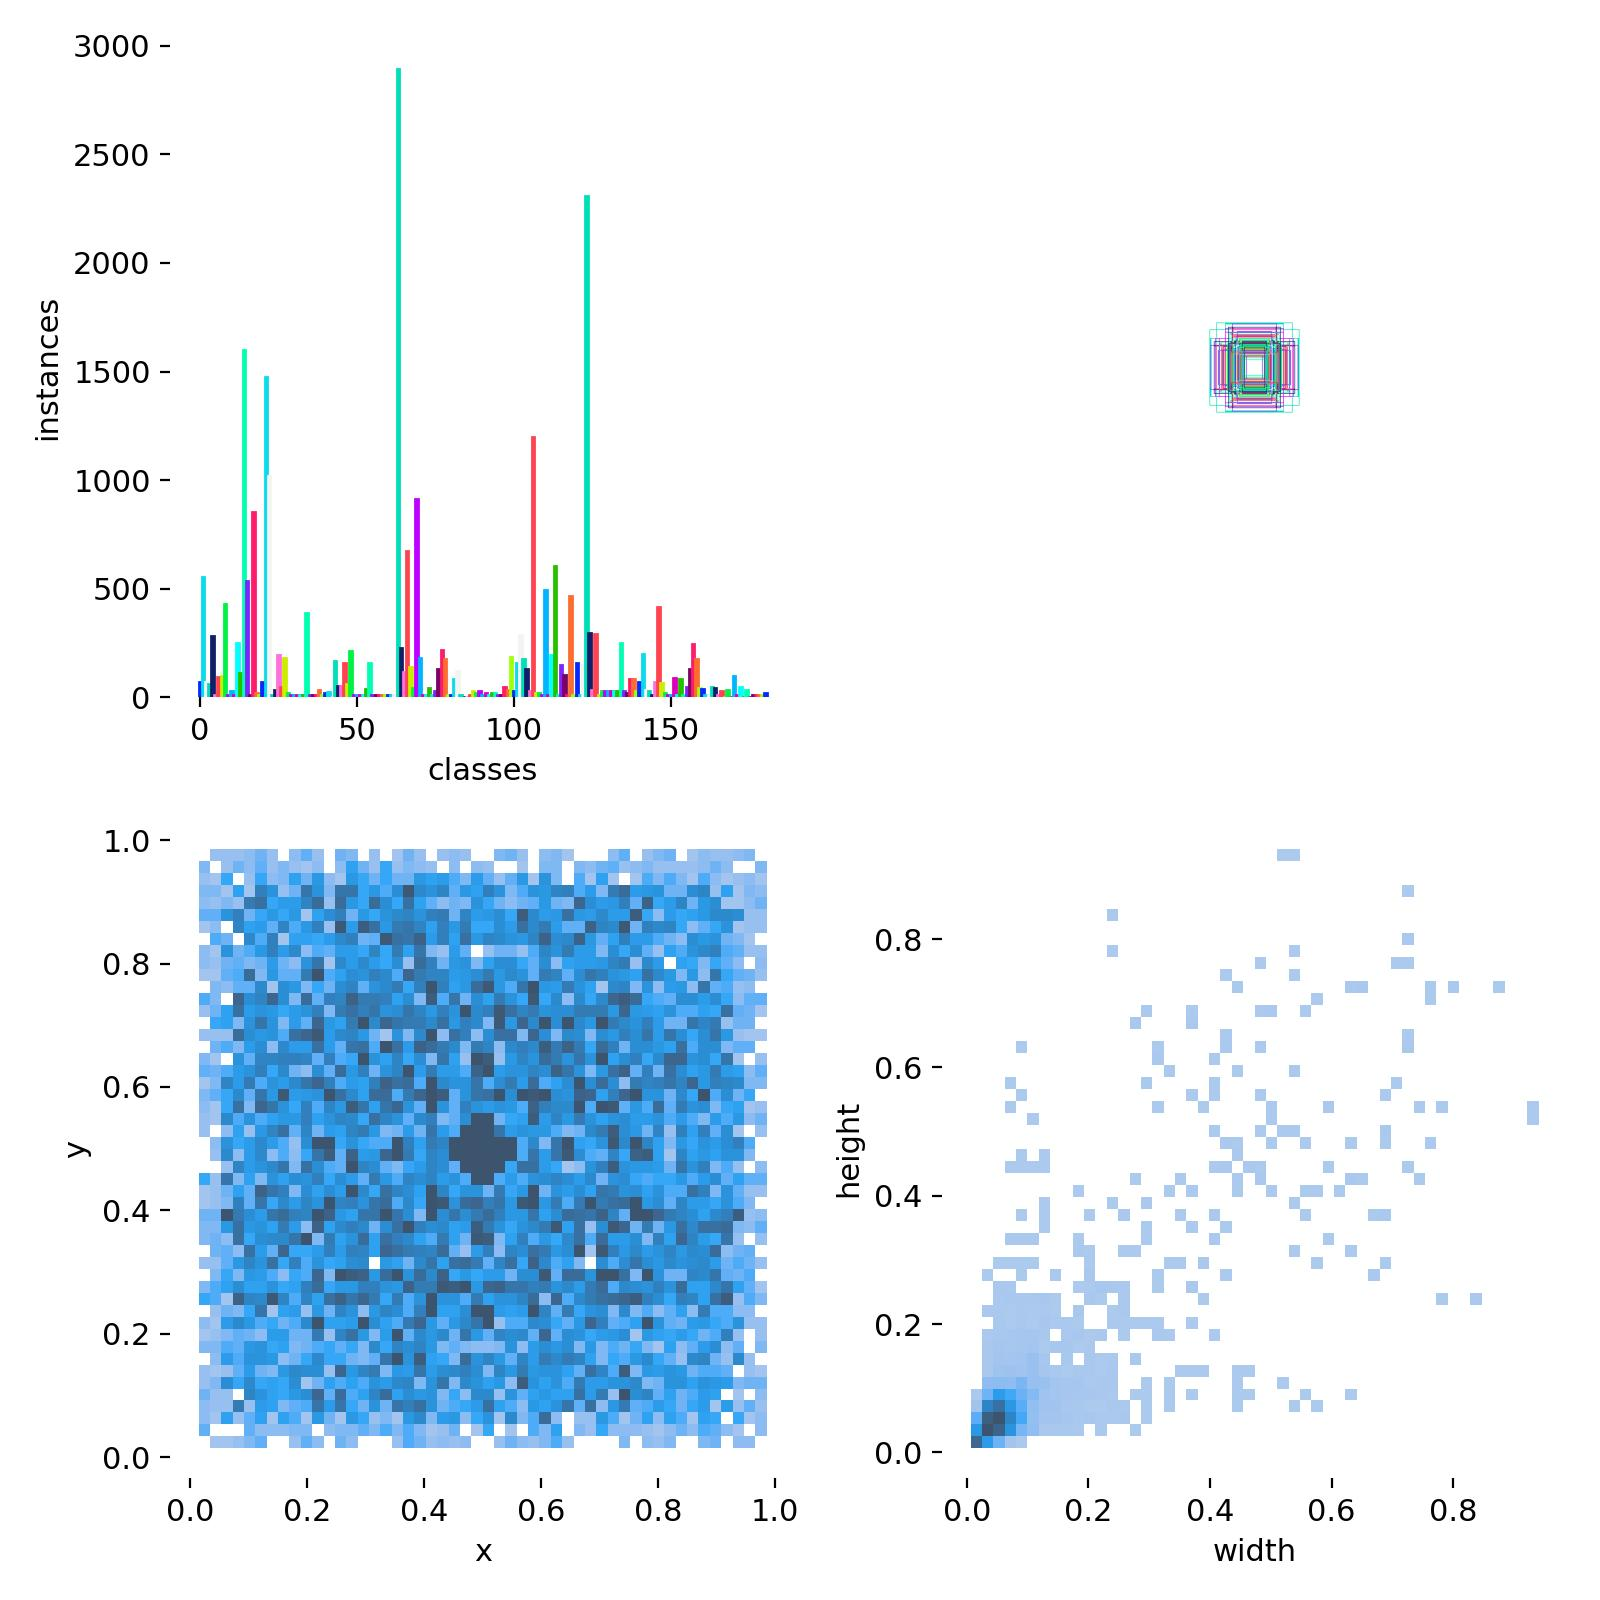

In [12]:
Image(filename=f'{home}/runs/detect/train/labels.jpg', width=600)

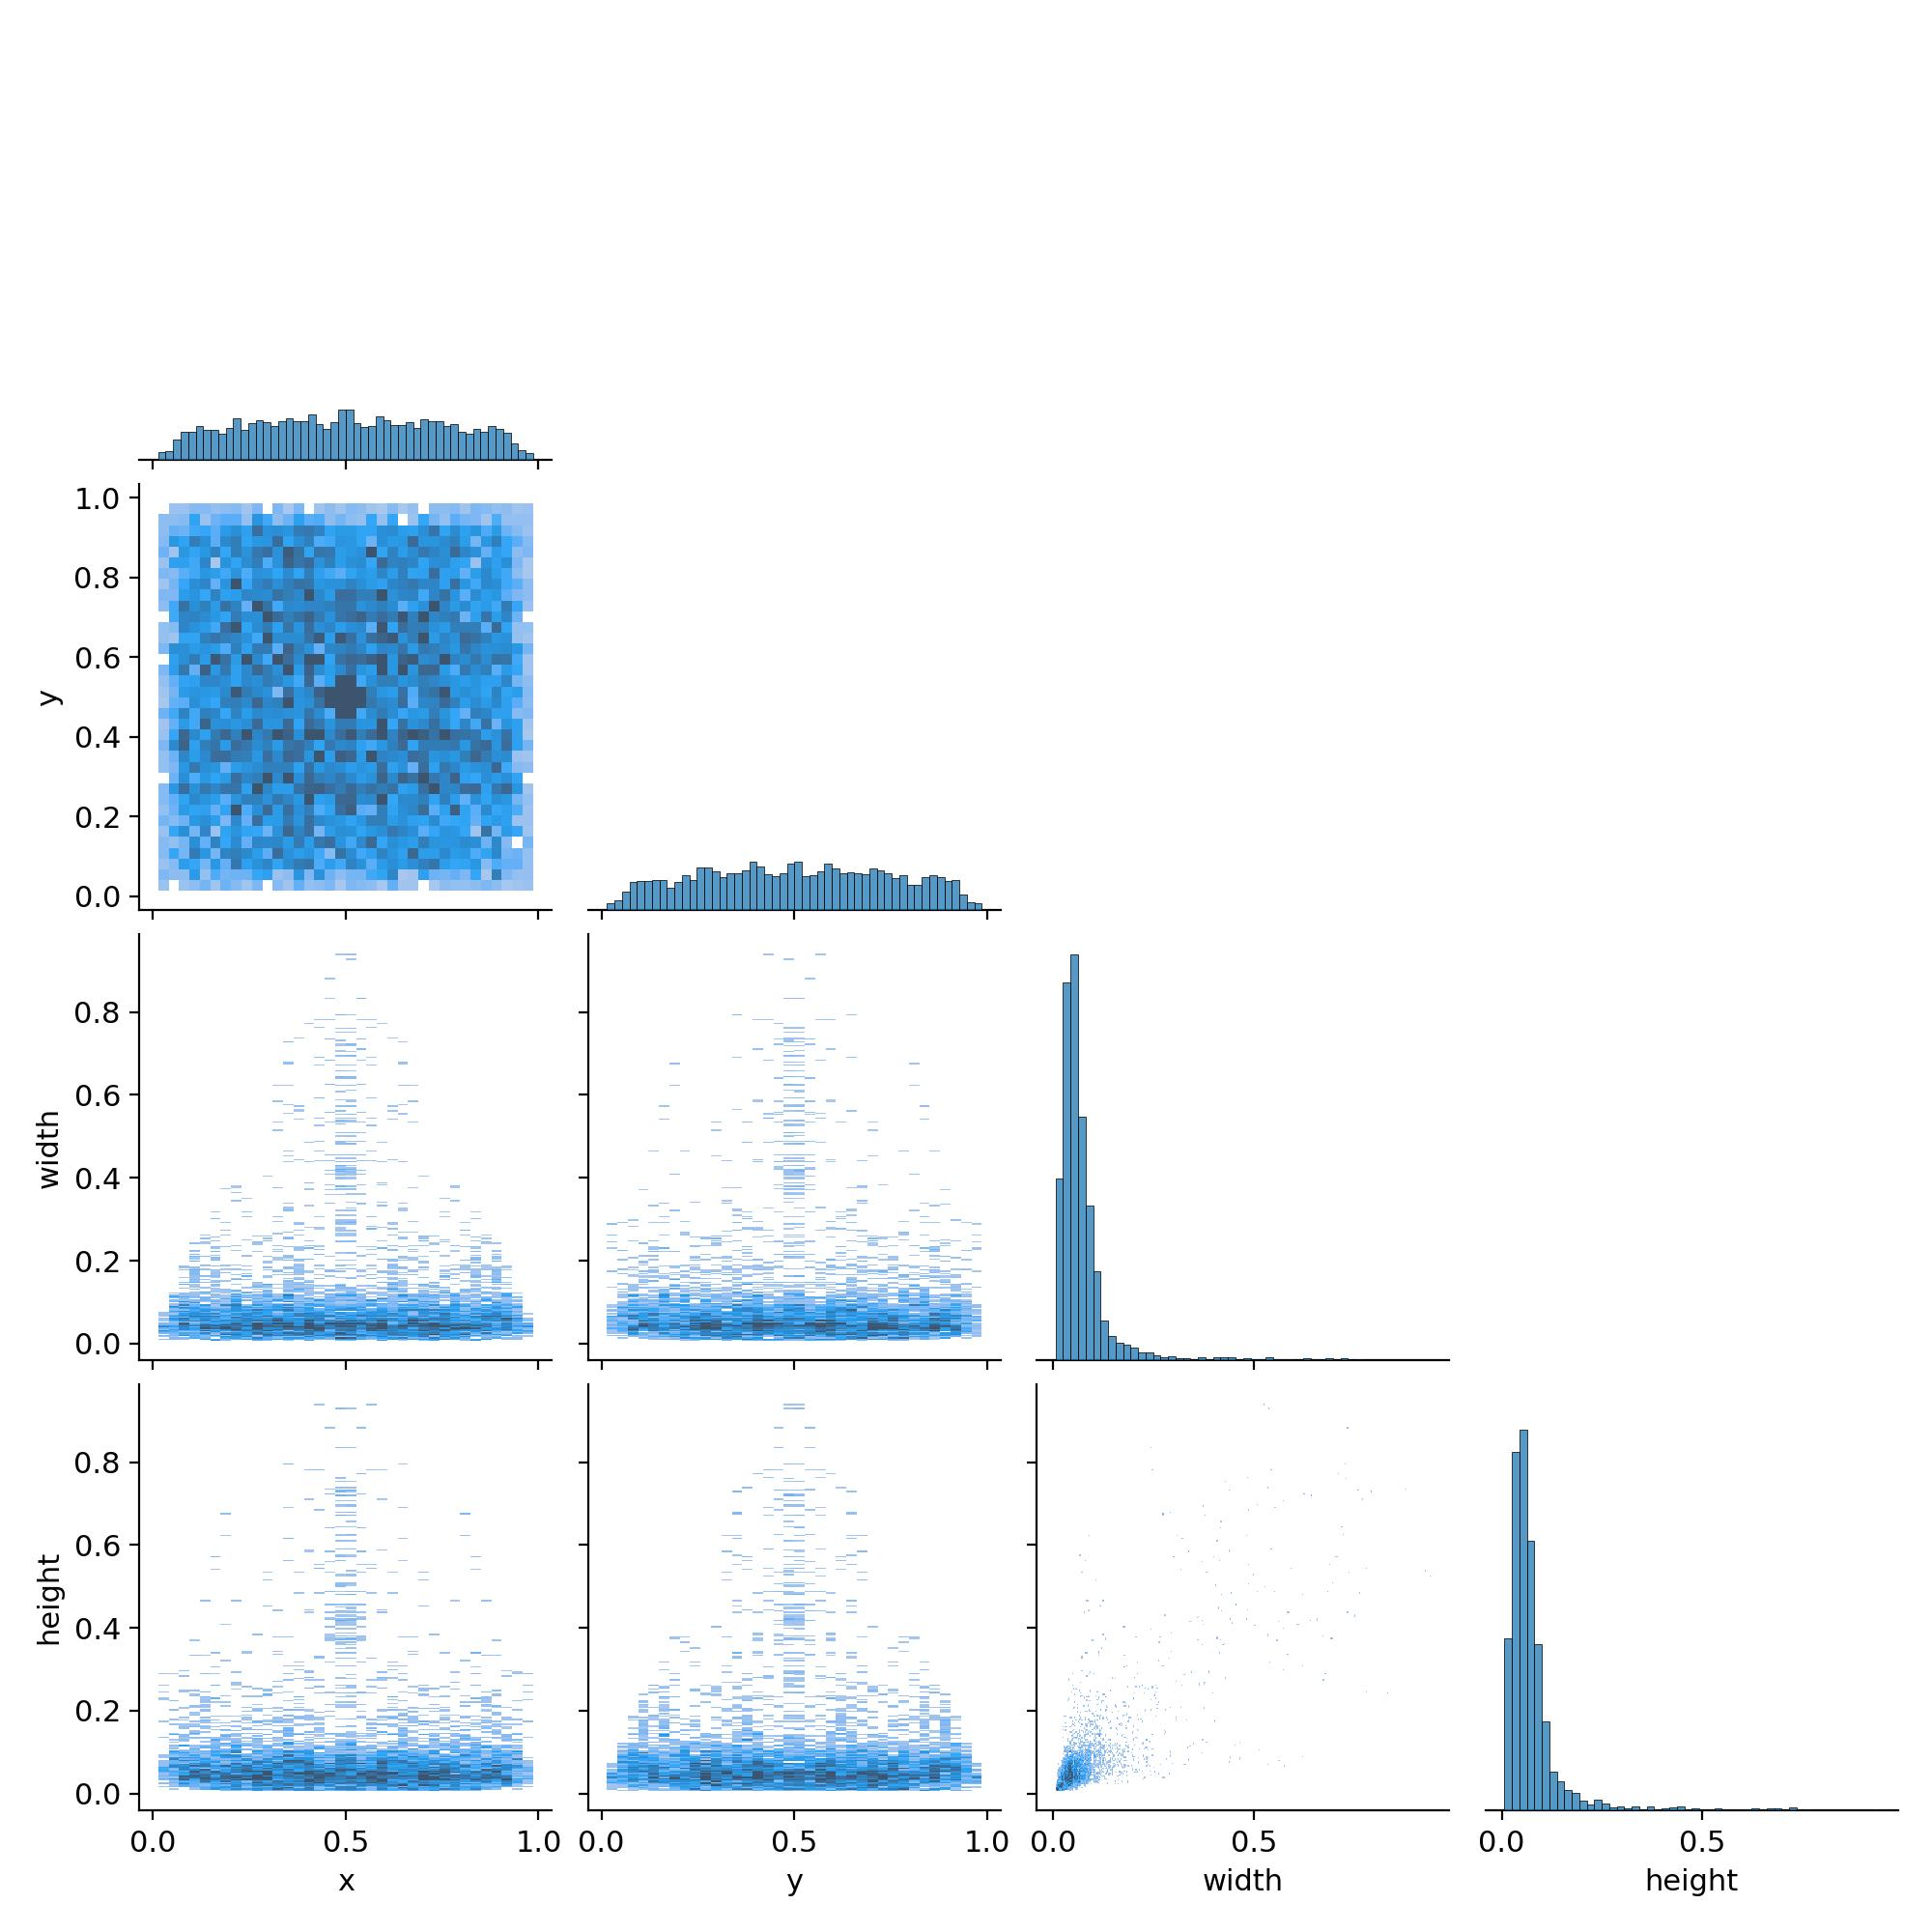

In [11]:
Image(filename=f'{home}/runs/detect/train/labels_correlogram.jpg', width=600)

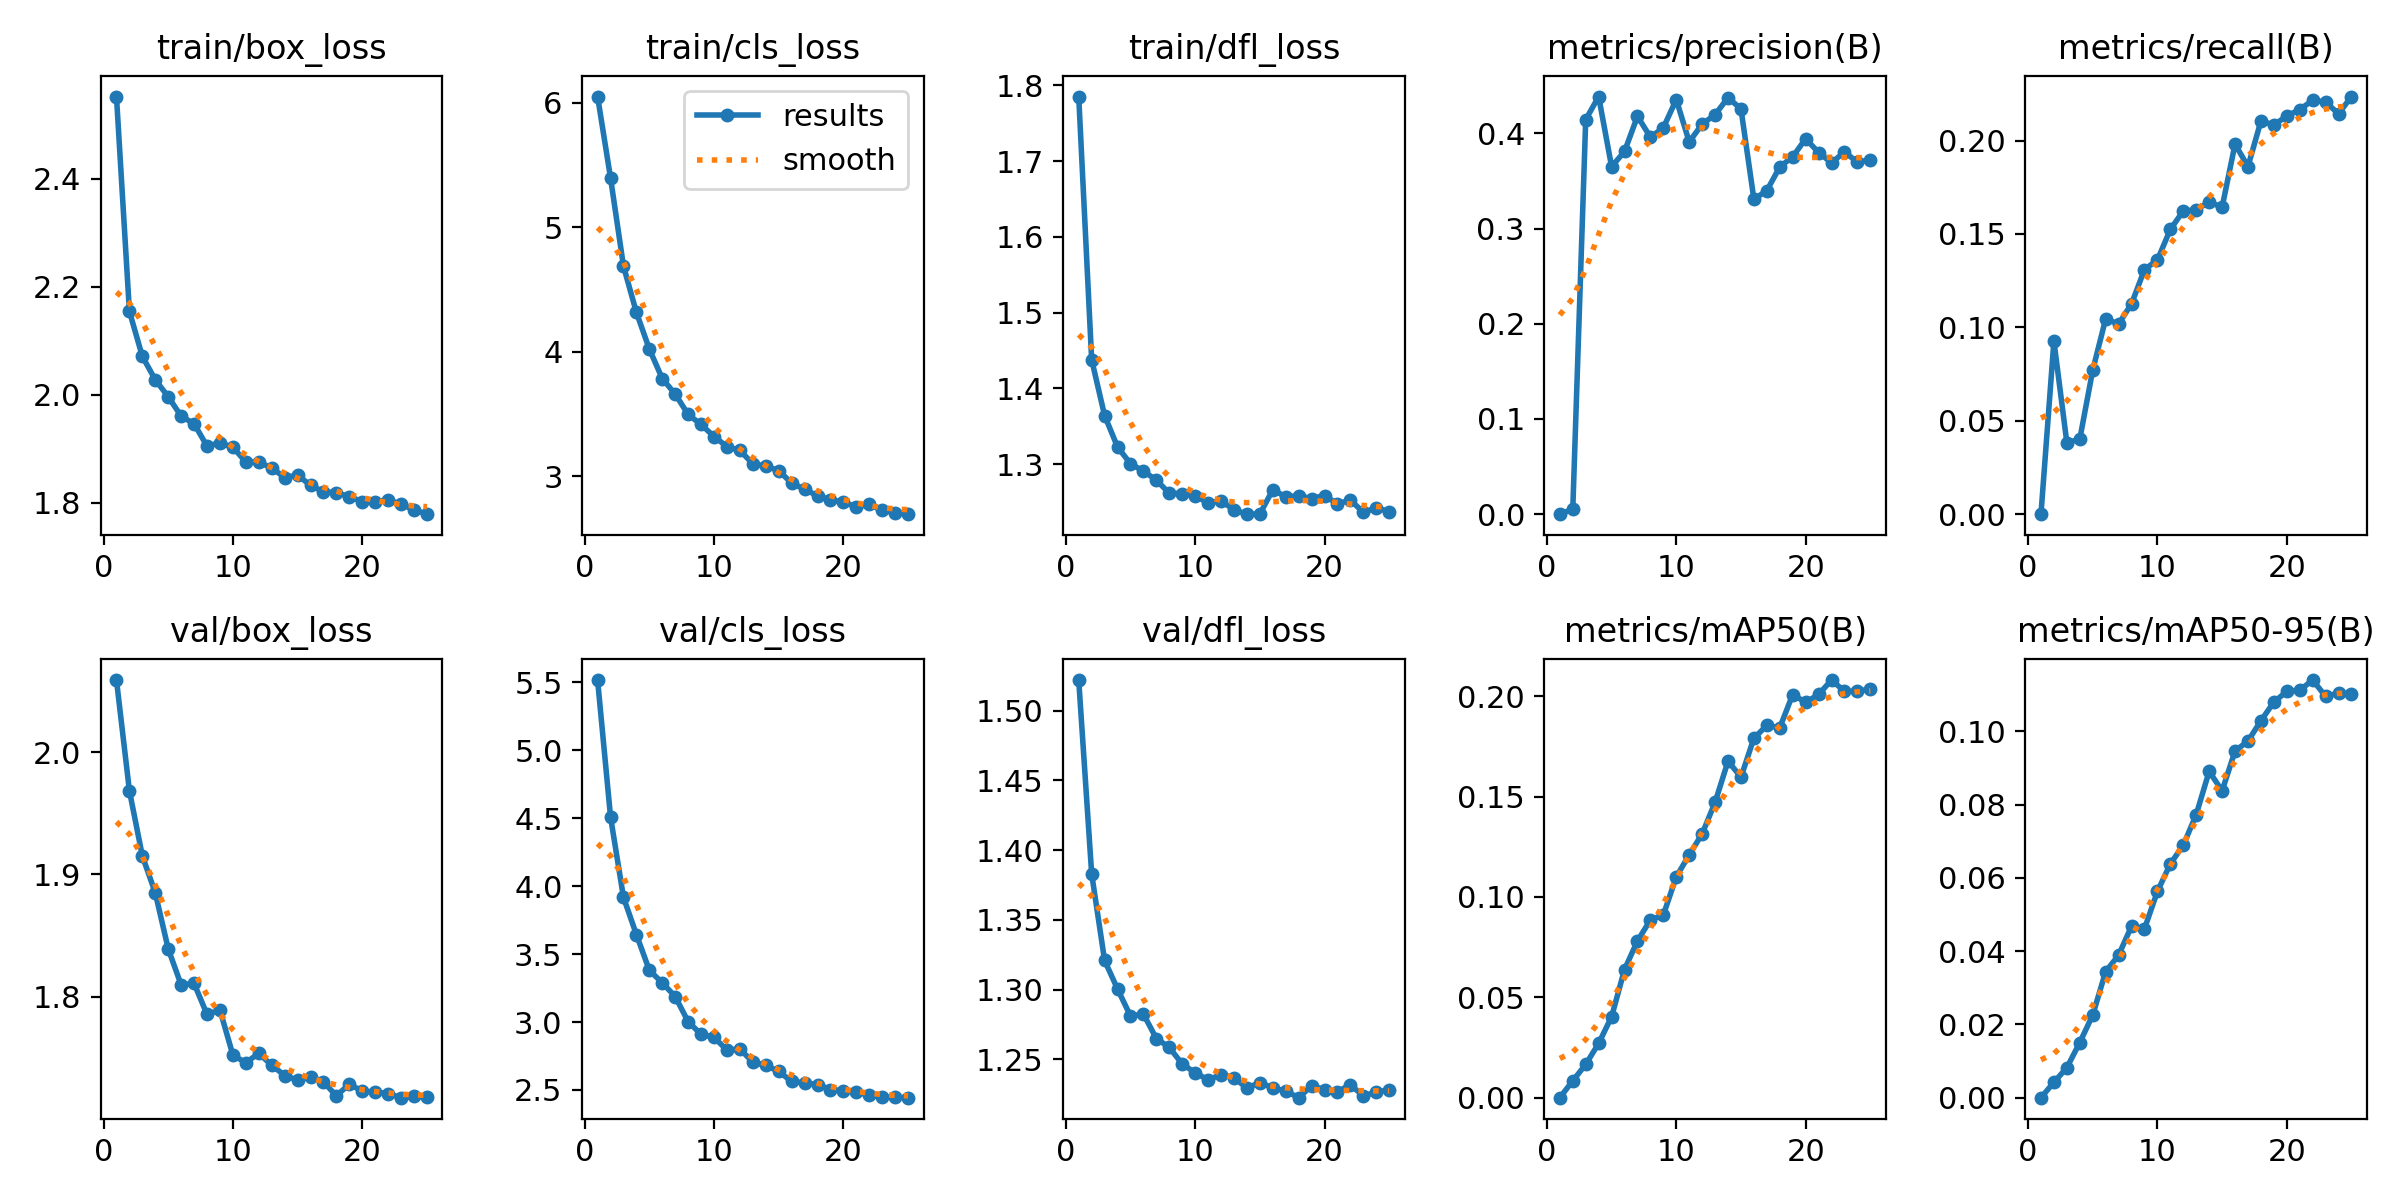

In [ ]:
Image(filename=f'{home}/runs/detect/train/results.png', width=600)

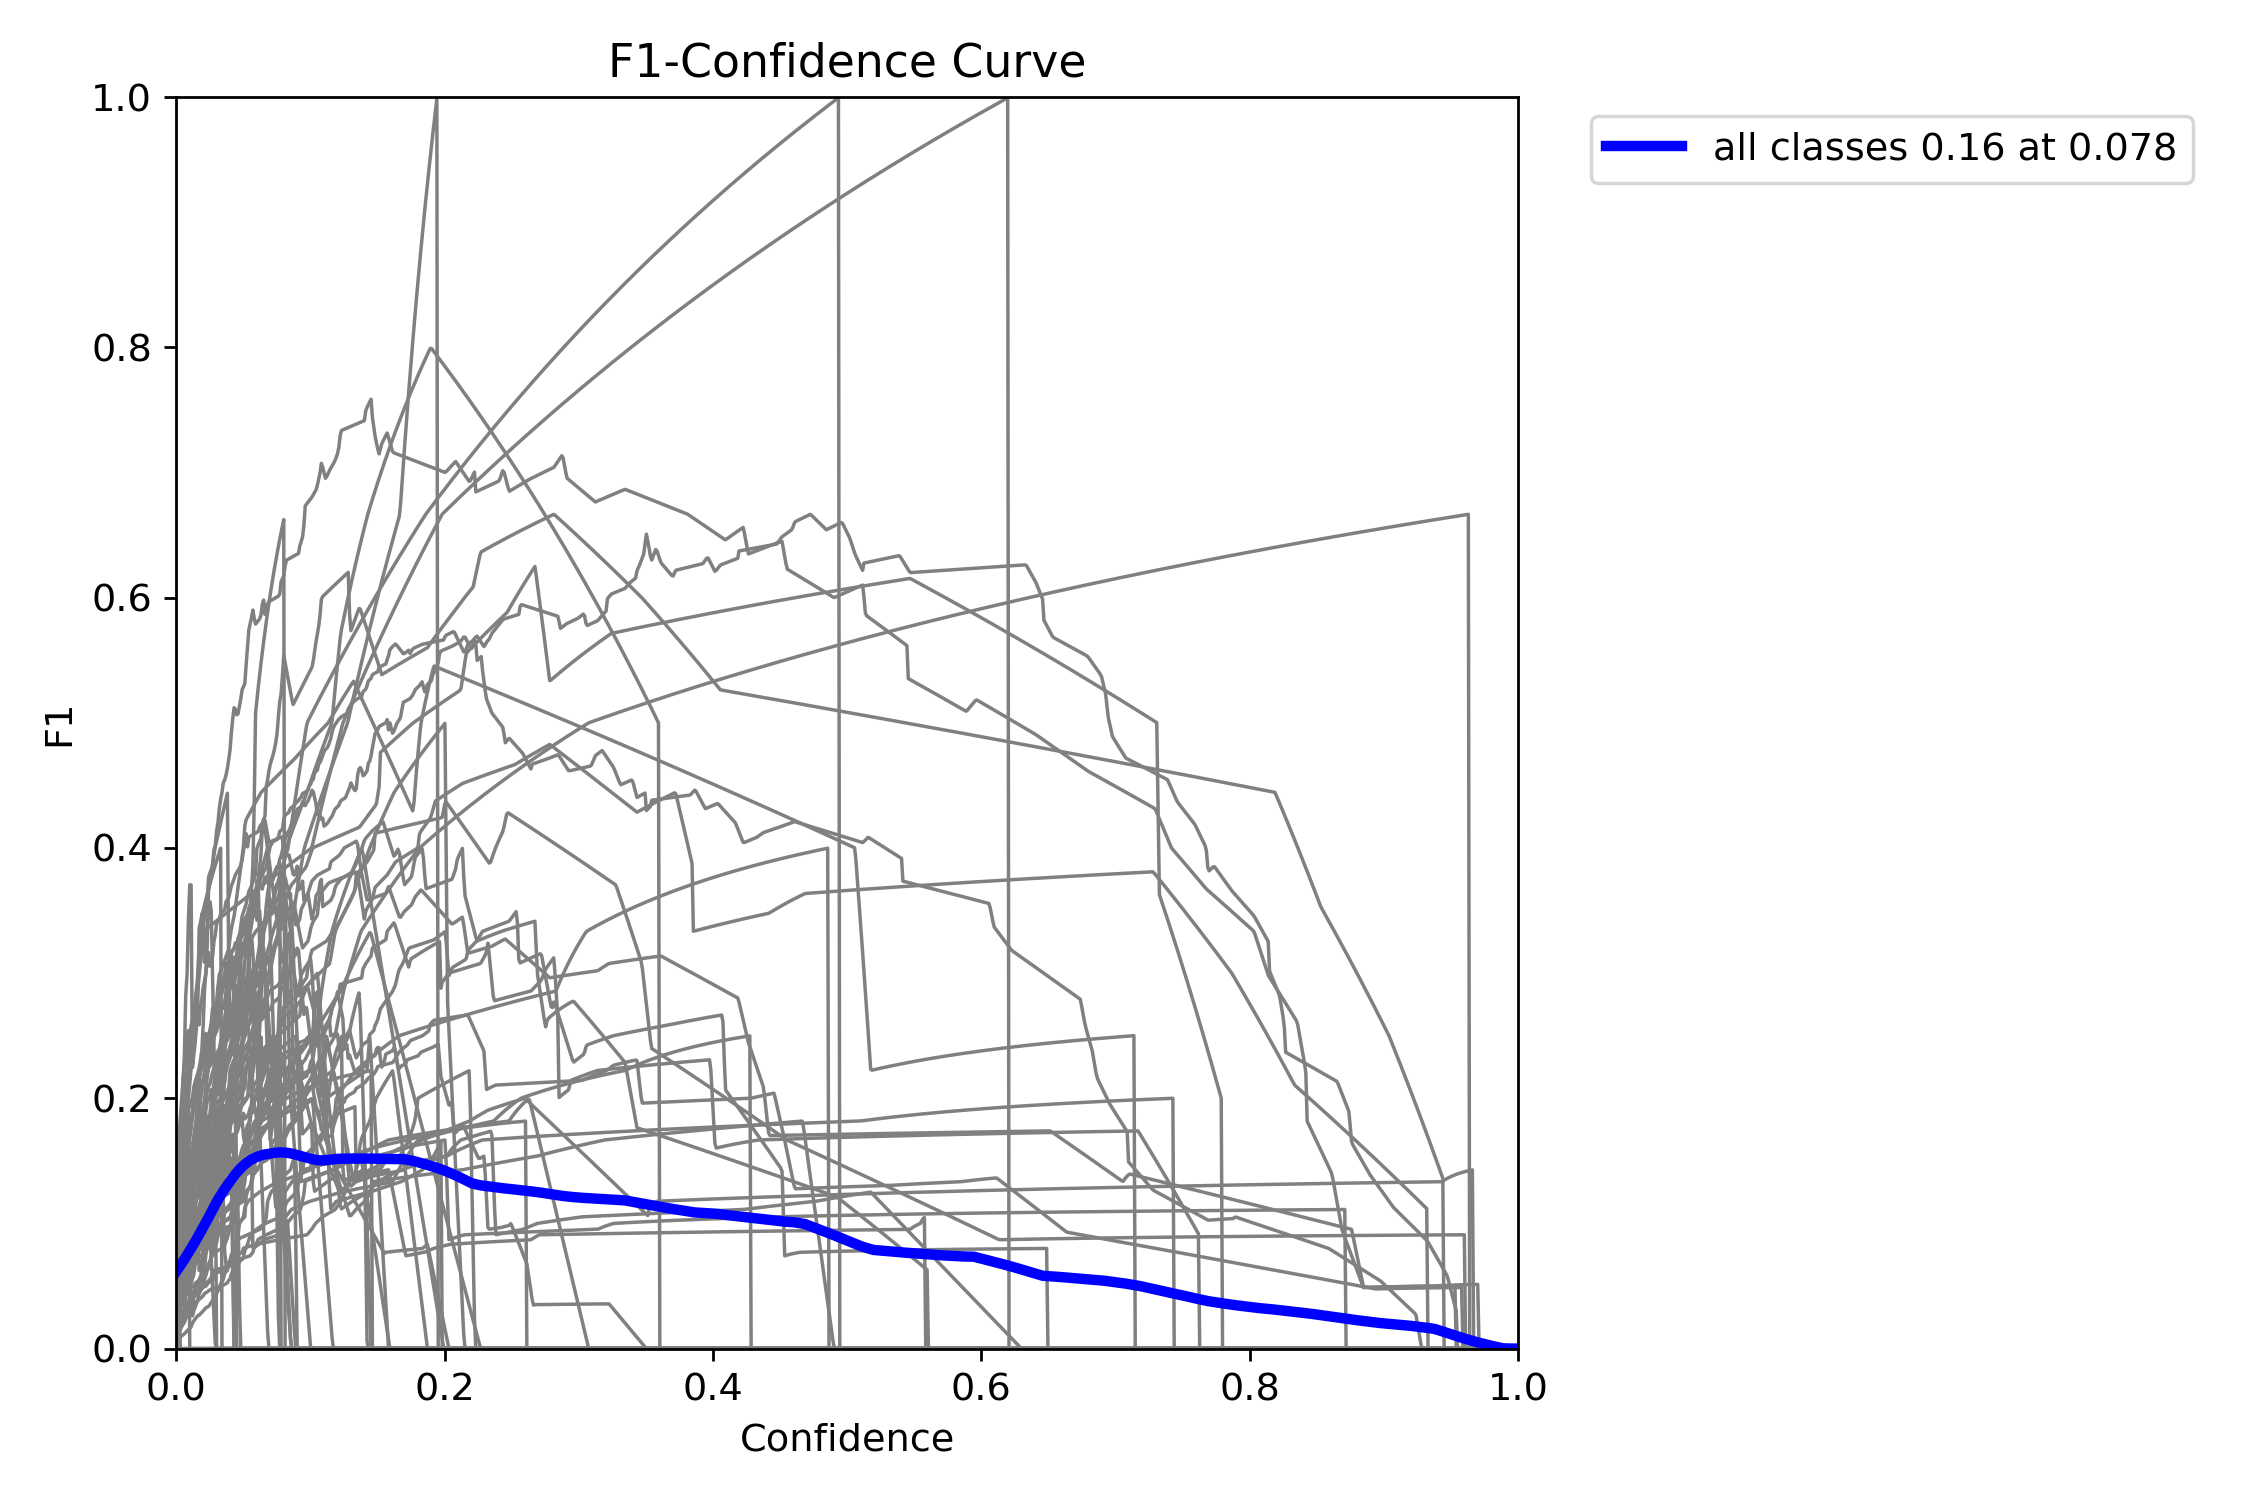

In [ ]:
Image(filename = f'{home}/runs/detect/train/F1_curve.png',width = 600)

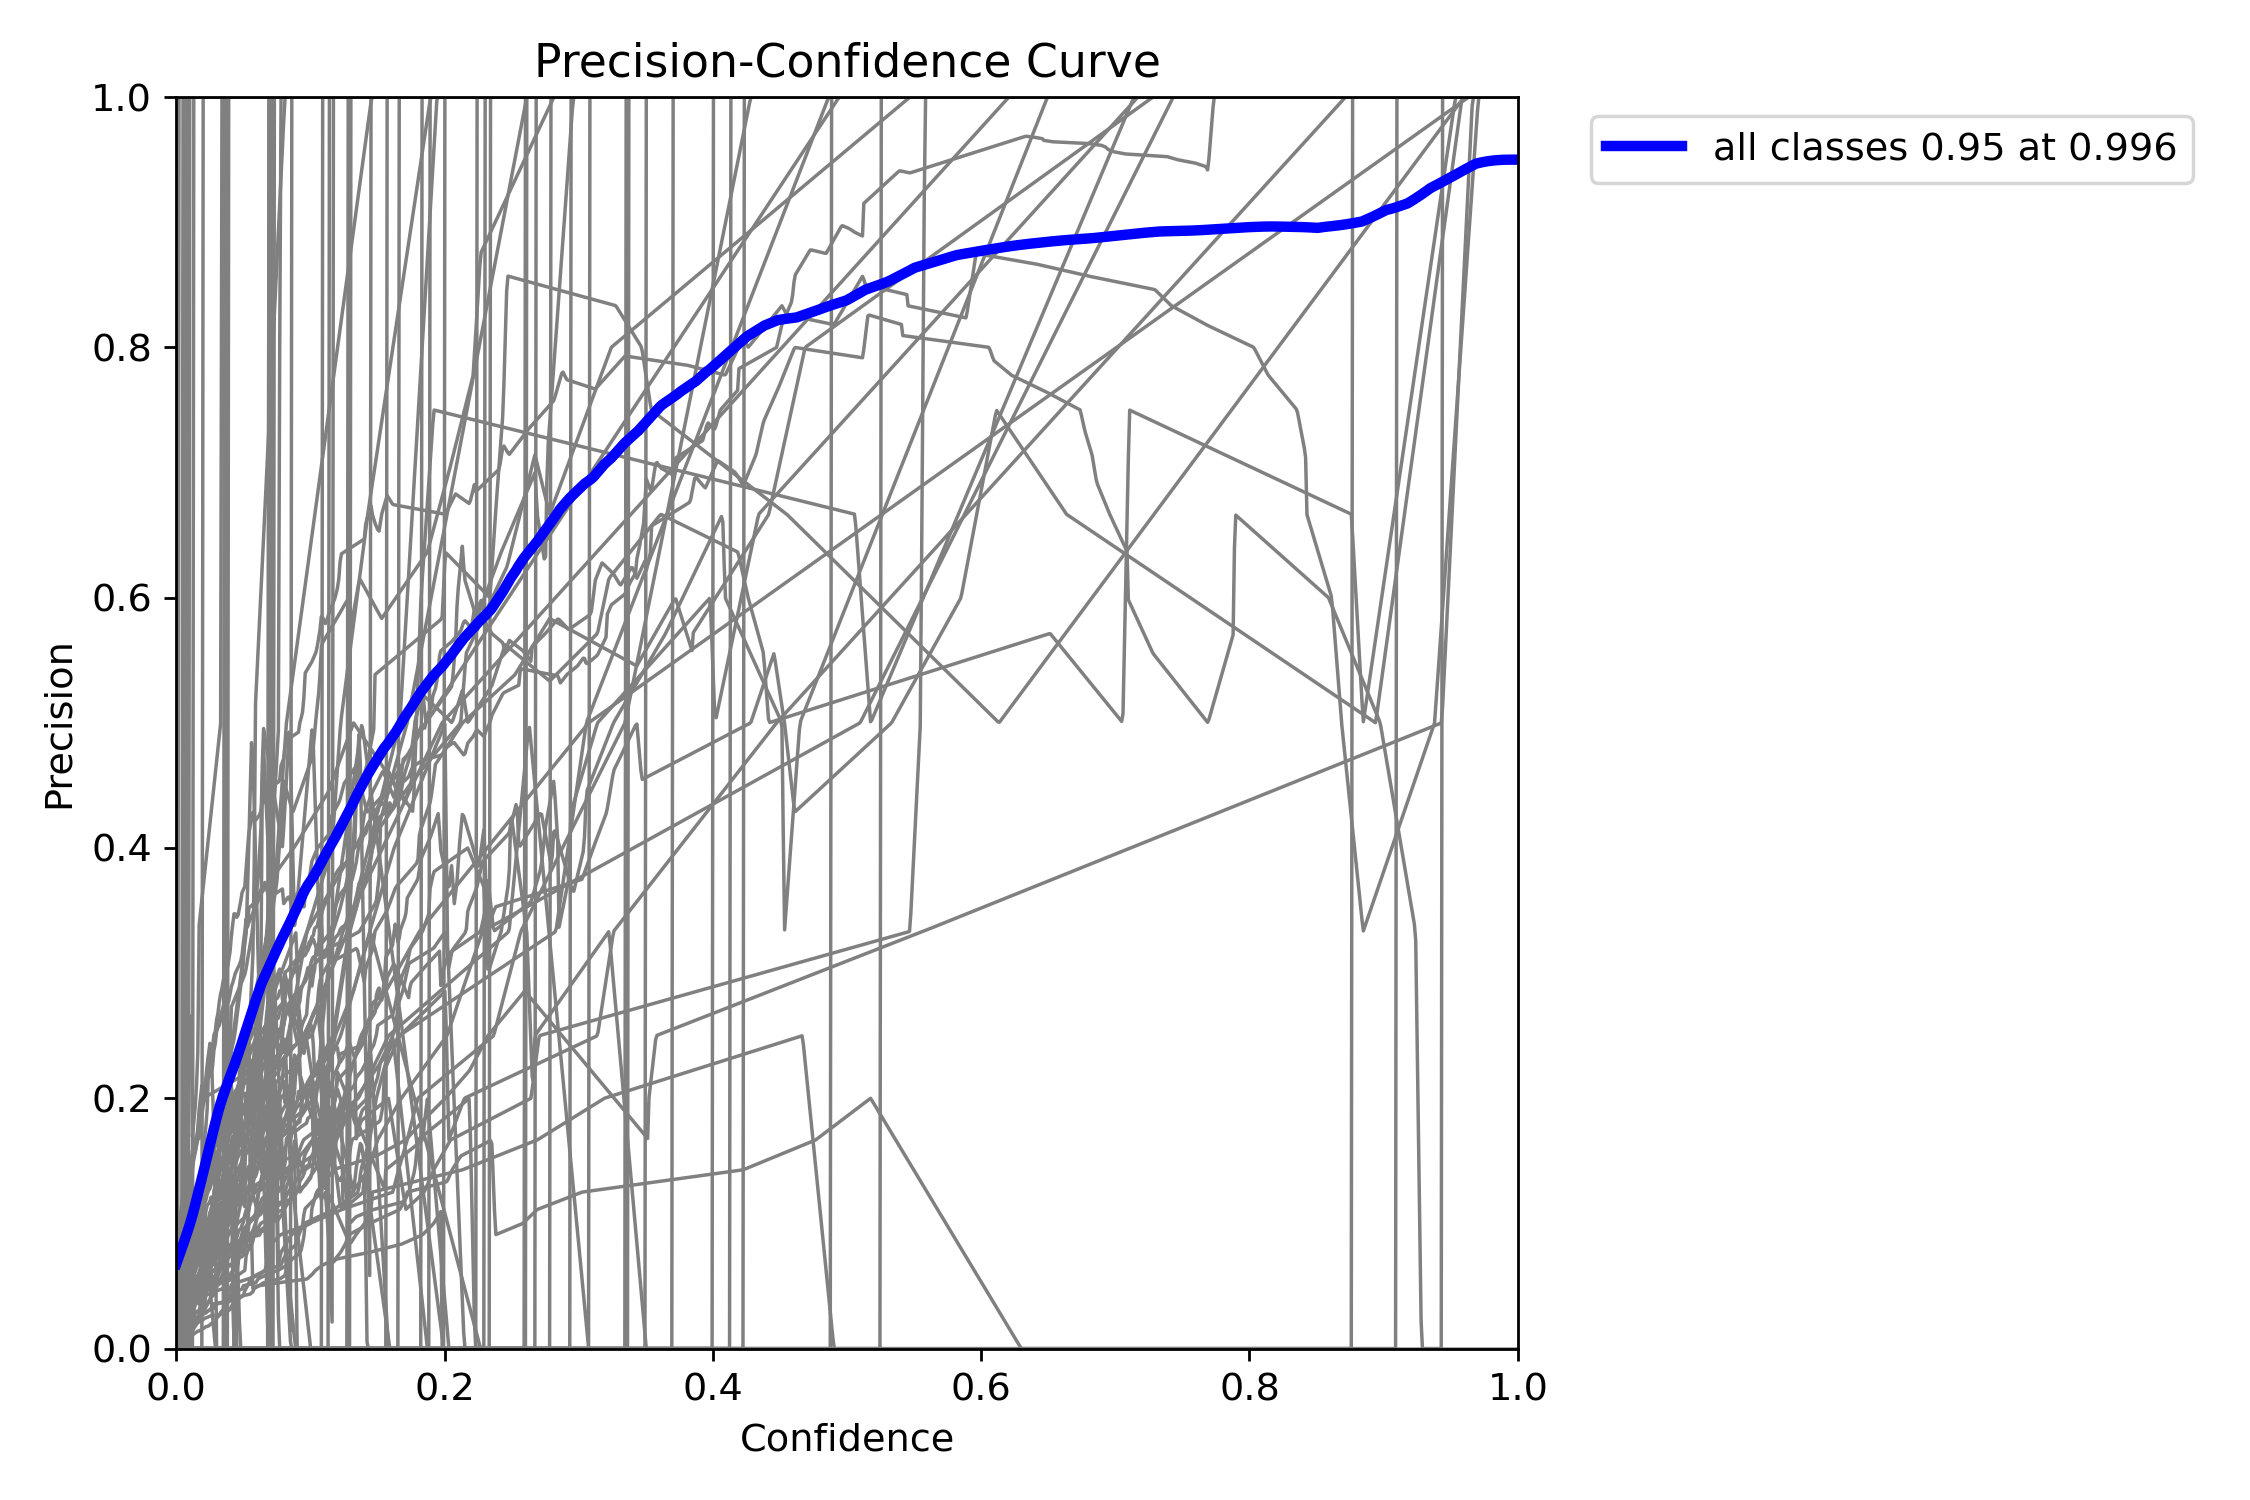

In [ ]:
Image(filename = f'{home}/runs/detect/train/P_curve.png',width = 600)

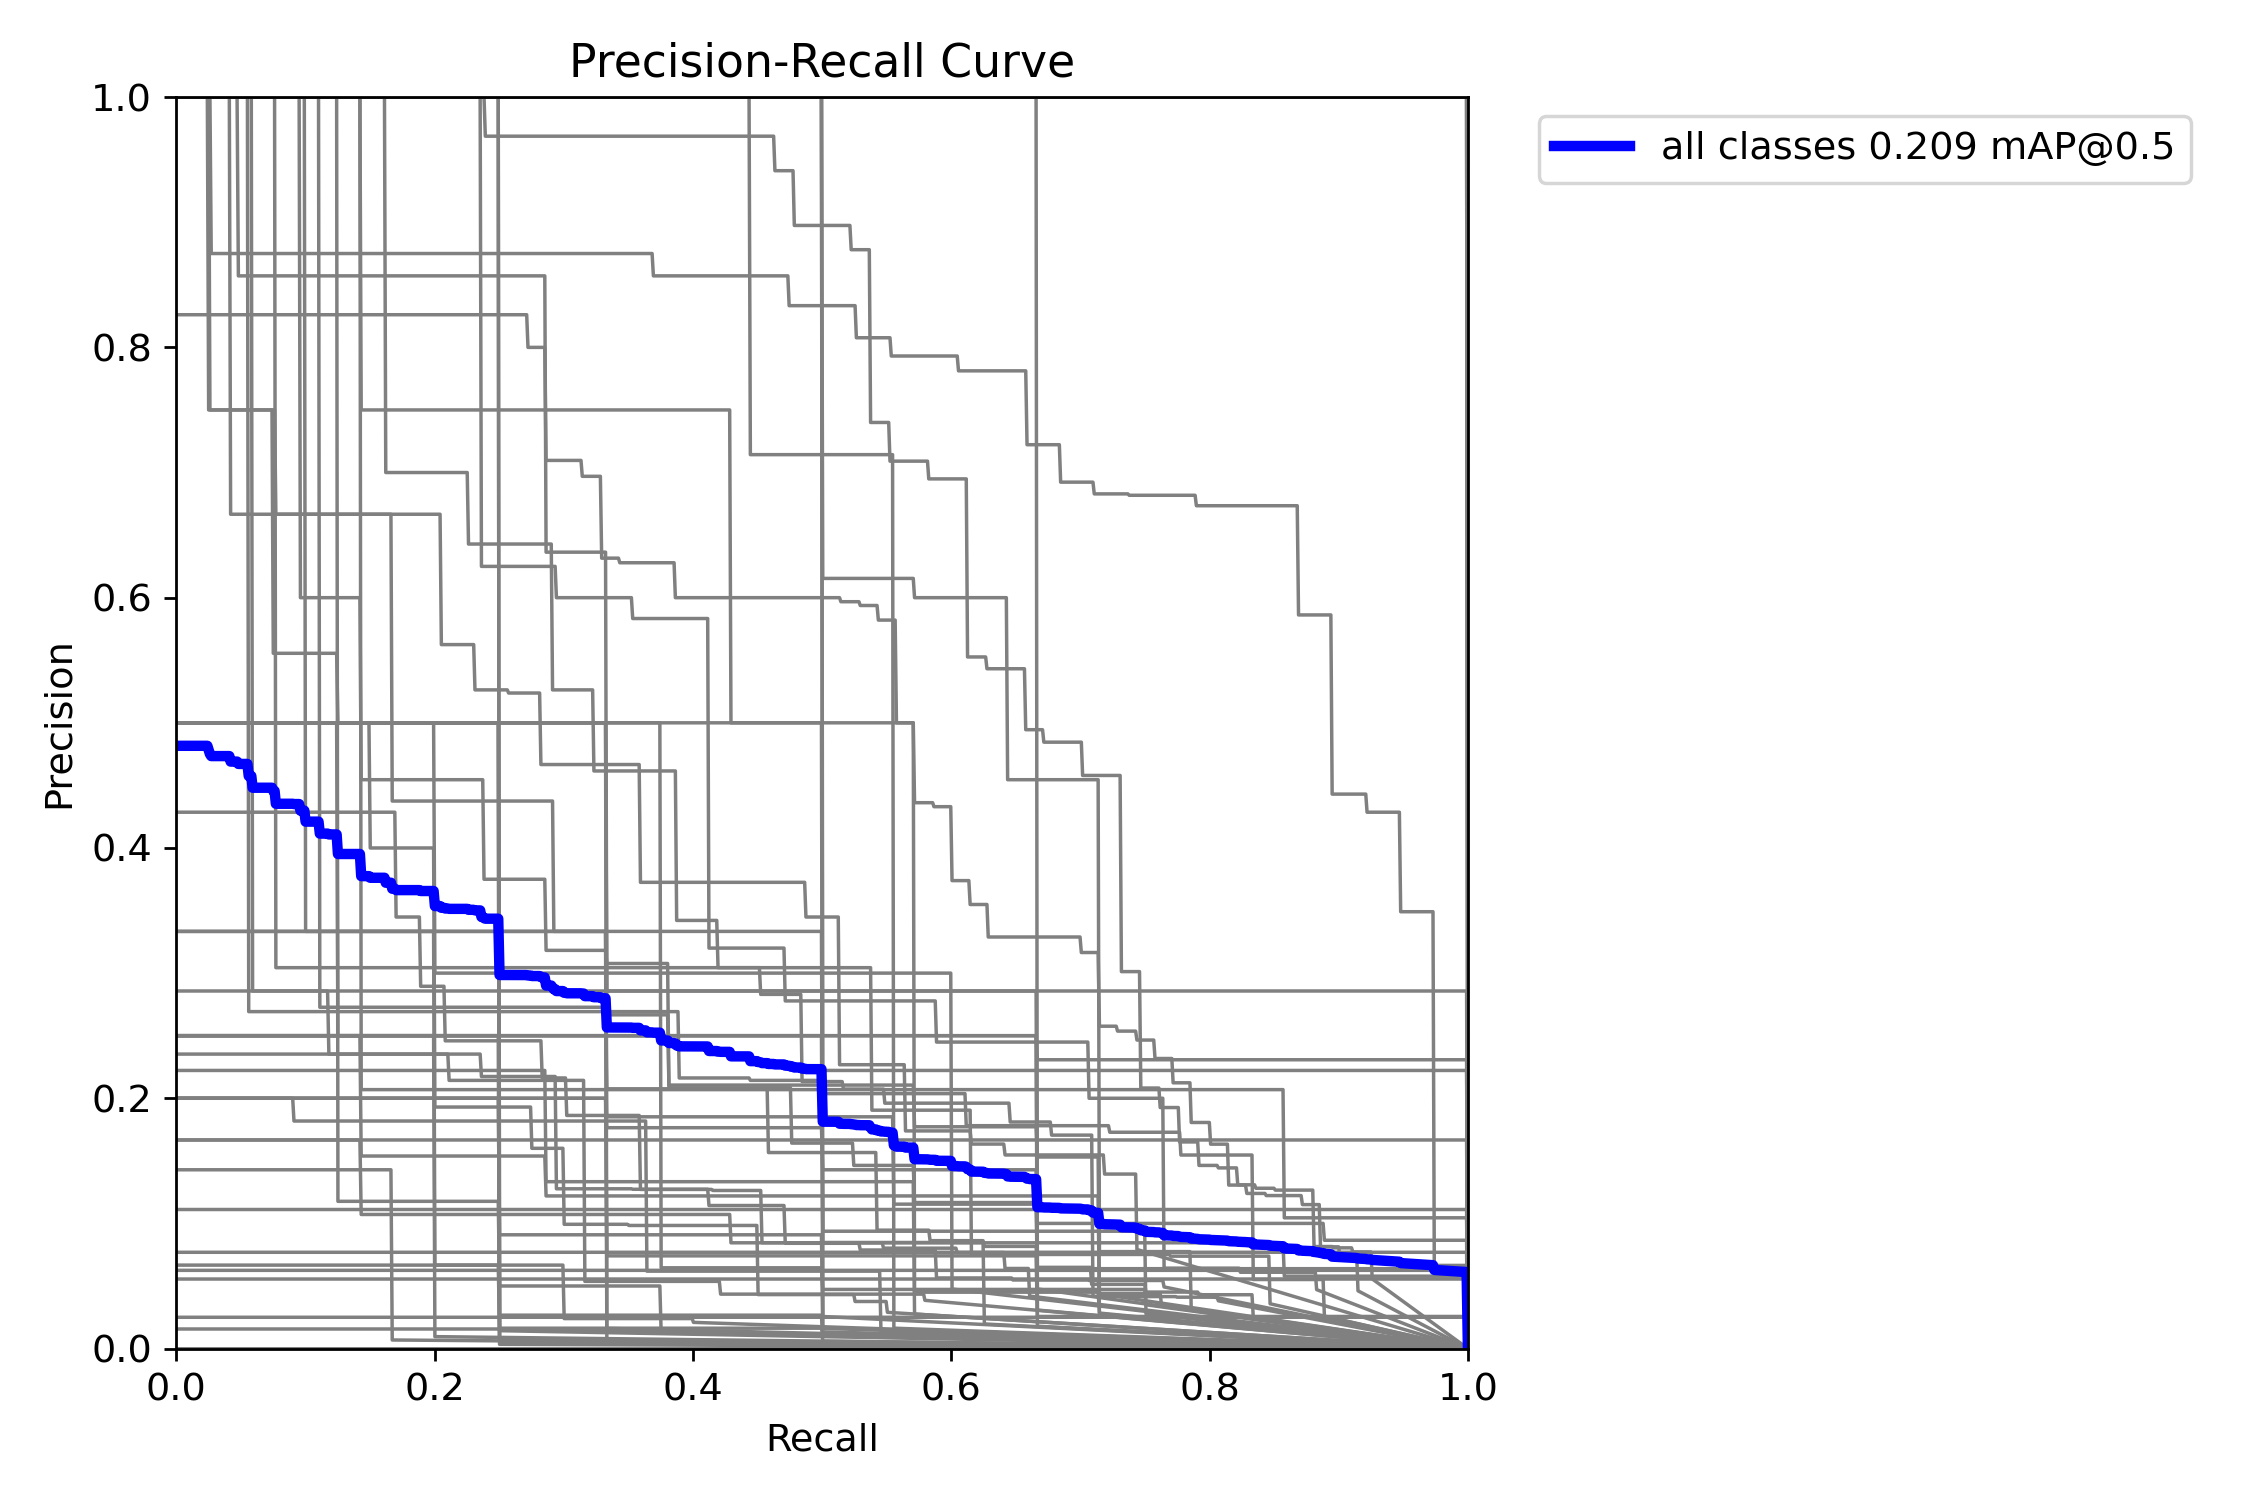

In [ ]:
Image(filename = f'{home}/runs/detect/train/PR_curve.png',width = 600)

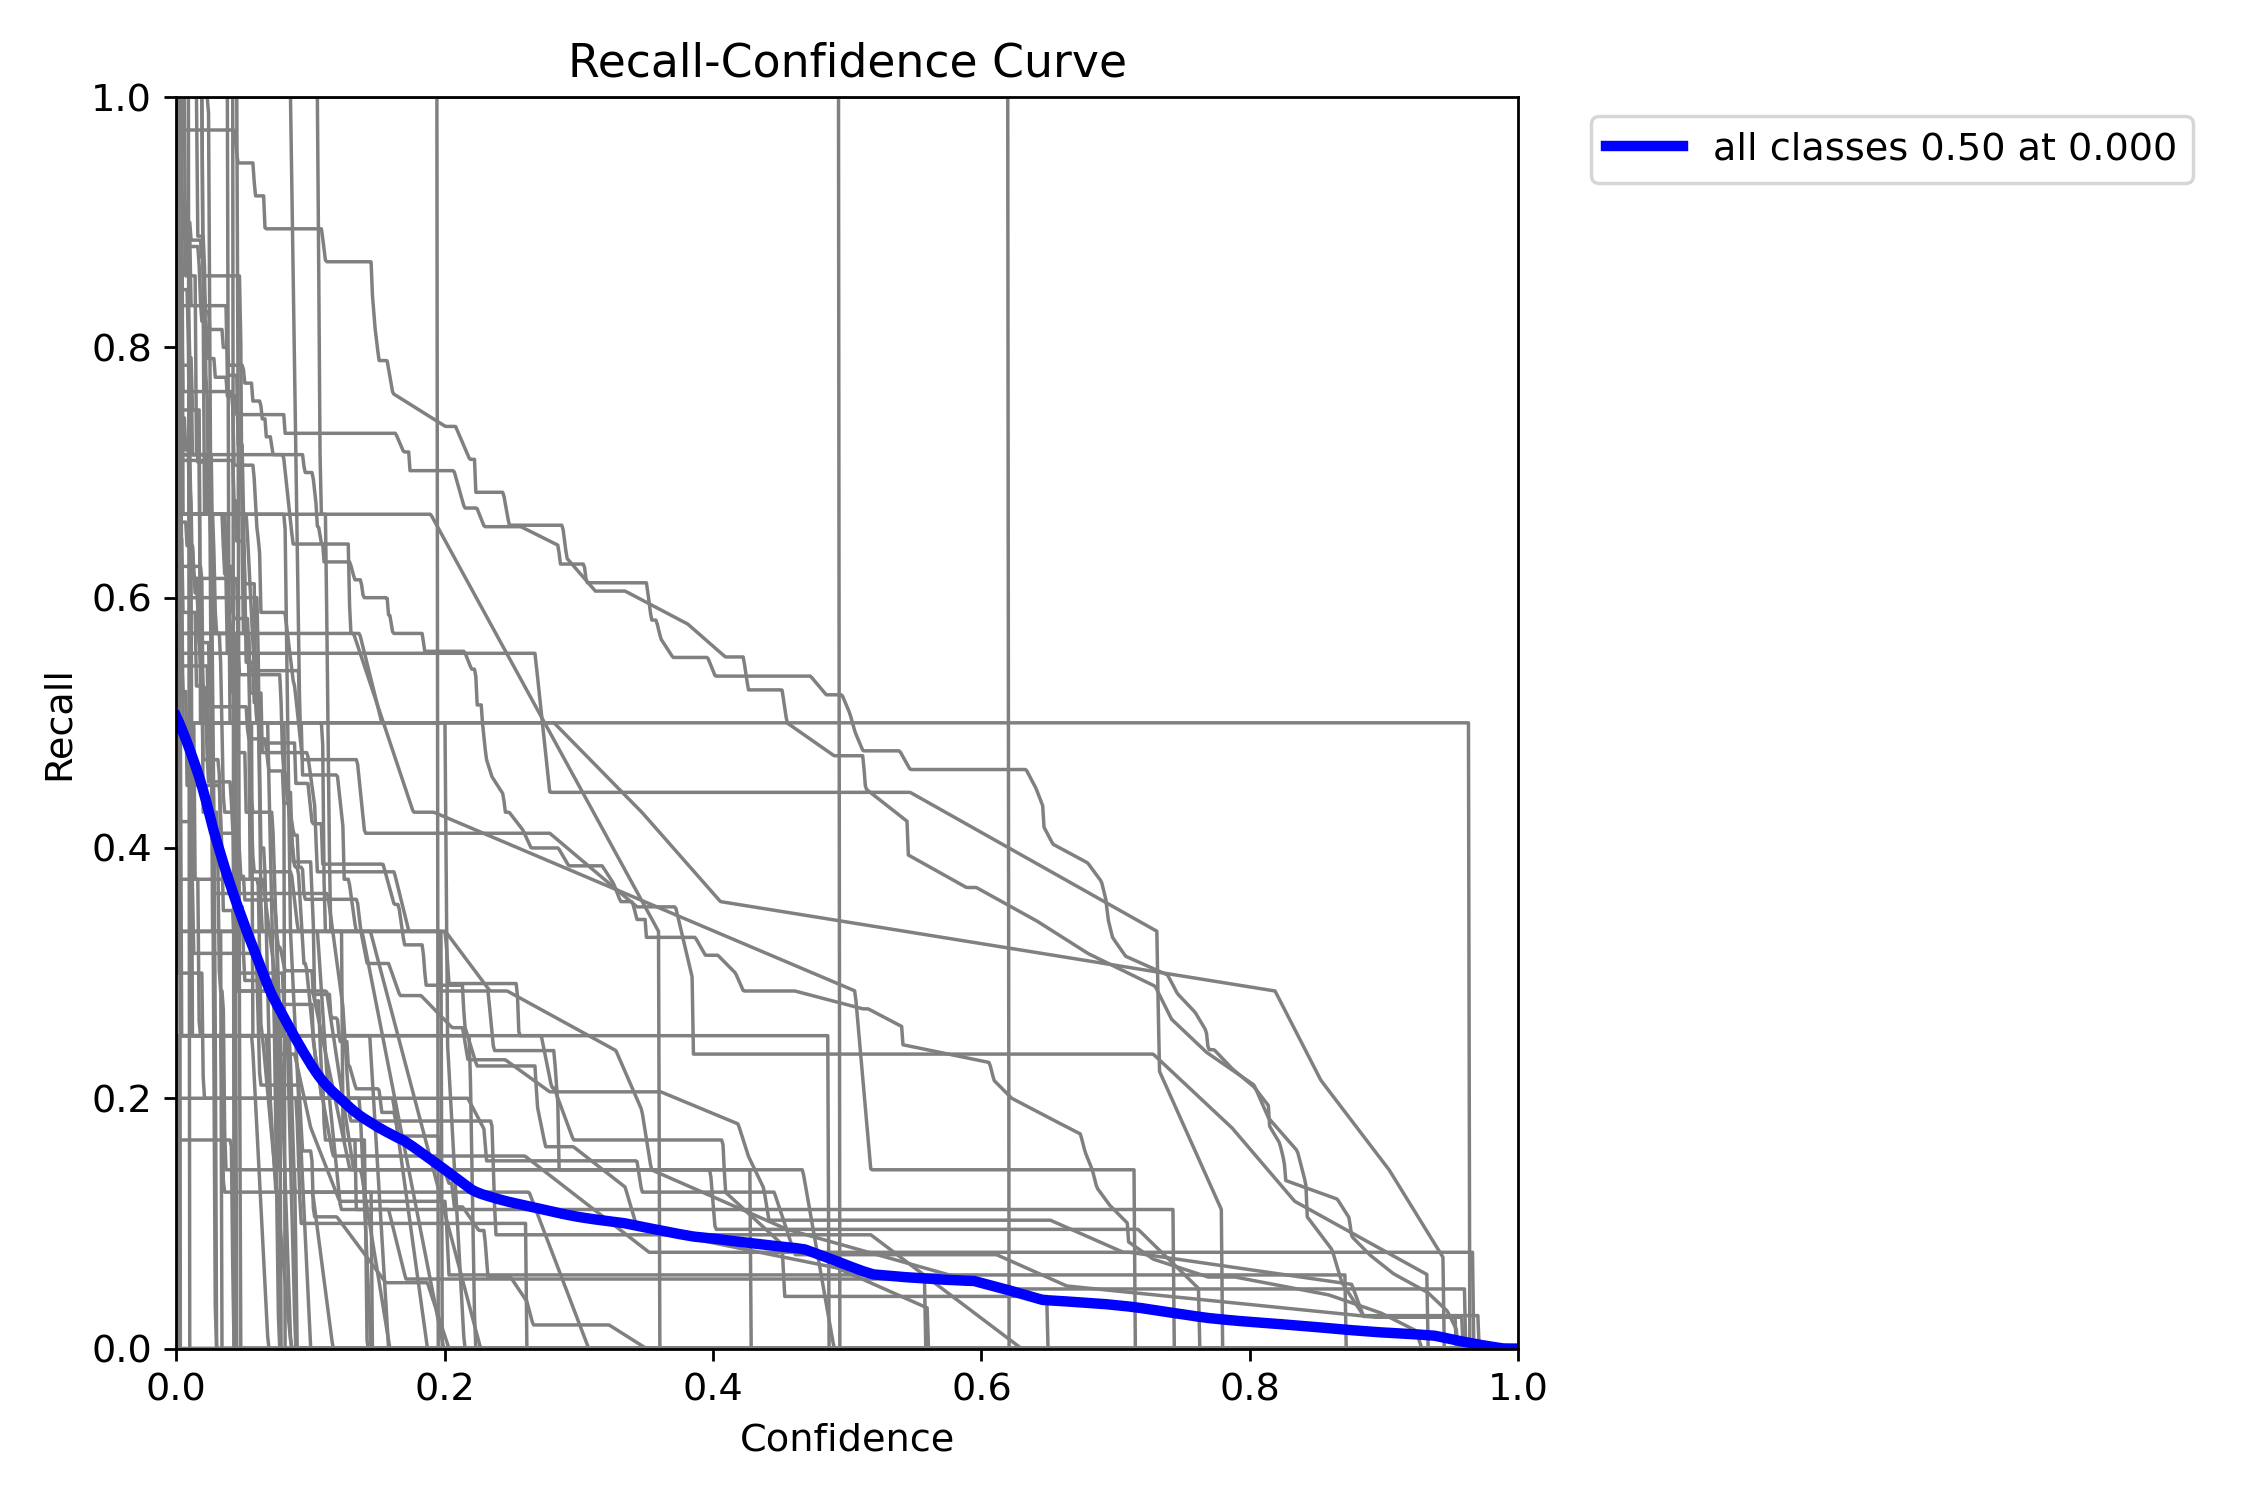

In [ ]:
Image(filename = f'{home}/runs/detect/train/R_curve.png',width = 600)

In [ ]:
import matplotlib.pyplot as plt
import glob
import cv2


cols = 6

images = glob.glob(f'{home}/runs/detect/predict/*.jpg')
a,f = plt.subplots(nrows = len(images)//cols + 1,ncols = cols,figsize = (48,40))

for i in range(len(images)//cols):
    for j in range(cols):
        f[i,j].imshow(cv2.imread(images[i + j]))
plt.tight_layout()
plt.show()



Output hidden; open in https://colab.research.google.com to view.

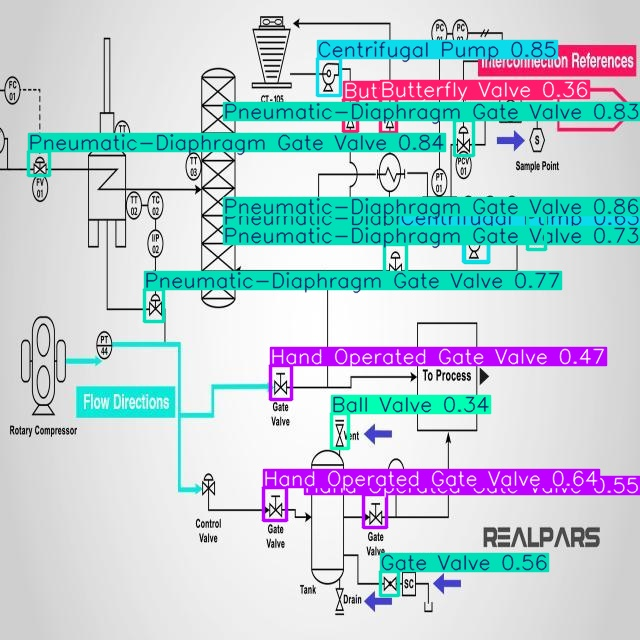

In [18]:
from IPython.display import Image, display

image = glob.glob(f'{home}/runs/detect/predict/*.jpg')[19]
Image(filename = image)

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
